In [5]:
import os

os.listdir("data")

['upi_transactions_raw.csv']

In [6]:
with open("data/upi_transactions_raw.csv", "rb") as f:
    print(f.read(20))

b'PK\x03\x04-\x00\x00\x00\x08\x00\x89|\x91T\xf9\n!\xe3\xff\xff'


In [7]:
import zipfile

with zipfile.ZipFile("data/upi_transactions_raw.csv", "r") as zip_ref:
    zip_ref.extractall("data")

In [8]:
import os

os.listdir("data")

['PS_20174392719_1491204439457_log.csv', 'upi_transactions_raw.csv']

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/PS_20174392719_1491204439457_log.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
import zipfile

with zipfile.ZipFile("data/upi_transactions_raw.csv", "r") as zip_ref:
    zip_ref.extractall("data")

In [11]:
import os

os.listdir("data")

['PS_20174392719_1491204439457_log.csv', 'upi_transactions_raw.csv']

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/PS_20174392719_1491204439457_log.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [13]:
df.shape

(6362620, 11)

In [14]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [16]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [19]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [20]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [21]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [24]:
## Initial Dataset Observations

- The dataset contains online payment transaction records.
- `nameOrig` represents sender account.
- `nameDest` represents receiver account.
- `step` represents transaction time in hours.
- `amount` represents transaction amount.
- `isFraud` is the main target column.
- The dataset is expected to be highly imbalanced because fraud transactions are usually very low compared to genuine transactions.#

In [25]:
df_upi = df.rename(columns={
    "step": "Transaction_Hour",
    "type": "Transaction_Type",
    "amount": "Transaction_Amount",
    "nameOrig": "Sender_ID",
    "oldbalanceOrg": "Sender_Old_Balance",
    "newbalanceOrig": "Sender_New_Balance",
    "nameDest": "Receiver_ID",
    "oldbalanceDest": "Receiver_Old_Balance",
    "newbalanceDest": "Receiver_New_Balance",
    "isFraud": "Fraud_Label",
    "isFlaggedFraud": "System_Flagged_Fraud"
})

df_upi.head()

,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,Fraud_Label,System_Flagged_Fraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [26]:
df_upi.columns

Index(['Transaction_Hour', 'Transaction_Type', 'Transaction_Amount',
       'Sender_ID', 'Sender_Old_Balance', 'Sender_New_Balance', 'Receiver_ID',
       'Receiver_Old_Balance', 'Receiver_New_Balance', 'Fraud_Label',
       'System_Flagged_Fraud'],
      dtype='object')

In [27]:
df_upi.shape

(6362620, 11)

In [28]:
df_upi["Fraud_Label"].value_counts()

Fraud_Label
0    6354407
1       8213
Name: count, dtype: int64

In [29]:
df_upi.insert(0, "Transaction_ID", range(1, len(df_upi) + 1))

df_upi.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,Fraud_Label,System_Flagged_Fraud
0,1,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,2,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,3,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,4,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,5,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [30]:
df_upi["Transaction_Day"] = (df_upi["Transaction_Hour"] // 24) + 1

df_upi[["Transaction_Hour", "Transaction_Day"]].head()

,Transaction_Hour,Transaction_Day
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [31]:
df_upi["Hour_Of_Day"] = df_upi["Transaction_Hour"] % 24

df_upi[["Transaction_Hour", "Transaction_Day", "Hour_Of_Day"]].head()

,Transaction_Hour,Transaction_Day,Hour_Of_Day
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1


In [32]:
df_upi.to_csv("data/upi_transactions_processed_step1.csv", index=False)

In [33]:
import os

os.listdir("data")

['PS_20174392719_1491204439457_log.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_raw.csv']

In [ ]:
## UPI-Style Schema Conversion

The original online payment dataset was converted into a UPI-like transaction schema.

- `nameOrig` was renamed as `Sender_ID`
- `nameDest` was renamed as `Receiver_ID`
- `step` was renamed as `Transaction_Hour`
- `amount` was renamed as `Transaction_Amount`
- `isFraud` was renamed as `Fraud_Label`

Additional time-based columns were created:

- `Transaction_Day`
- `Hour_Of_Day`

This schema will help build transaction-level, account-level, temporal, and graph-based fraud risk features.

In [34]:
df_upi.insert(0, "Transaction_ID", range(1, len(df_upi) + 1))

df_upi.head()

ValueError: cannot insert Transaction_ID, already exists

In [35]:
df_upi.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,Fraud_Label,System_Flagged_Fraud,Transaction_Day,Hour_Of_Day
0,1,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,1
1,2,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,1
2,3,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,1
3,4,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,1
4,5,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,1


In [36]:
df_upi["Transaction_Day"] = (df_upi["Transaction_Hour"] // 24) + 1

df_upi[["Transaction_Hour", "Transaction_Day"]].head()

,Transaction_Hour,Transaction_Day
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [37]:
df_upi["Hour_Of_Day"] = df_upi["Transaction_Hour"] % 24

df_upi[["Transaction_Hour", "Transaction_Day", "Hour_Of_Day"]].head()

,Transaction_Hour,Transaction_Day,Hour_Of_Day
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1


In [38]:
df_upi.shape

(6362620, 14)

In [39]:
df_upi.columns

Index(['Transaction_ID', 'Transaction_Hour', 'Transaction_Type',
       'Transaction_Amount', 'Sender_ID', 'Sender_Old_Balance',
       'Sender_New_Balance', 'Receiver_ID', 'Receiver_Old_Balance',
       'Receiver_New_Balance', 'Fraud_Label', 'System_Flagged_Fraud',
       'Transaction_Day', 'Hour_Of_Day'],
      dtype='object')

In [40]:
df_upi.to_csv("data/upi_transactions_processed_step1.csv", index=False)

In [41]:
import os

os.listdir("data")

['PS_20174392719_1491204439457_log.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_raw.csv']

In [42]:
fraud_count = df_upi["Fraud_Label"].value_counts()
fraud_count

Fraud_Label
0    6354407
1       8213
Name: count, dtype: int64

In [43]:
fraud_percentage = df_upi["Fraud_Label"].value_counts(normalize=True) * 100
fraud_percentage

Fraud_Label
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [44]:
fraud_summary = pd.DataFrame({
    "Count": fraud_count,
    "Percentage": fraud_percentage
})

fraud_summary

,Count,Percentage
Fraud_Label,,
0,6354407,99.870918
1,8213,0.129082


In [45]:
fraud_summary.index = ["Genuine", "Fraud"]

fraud_summary

,Count,Percentage
Genuine,6354407,99.870918
Fraud,8213,0.129082


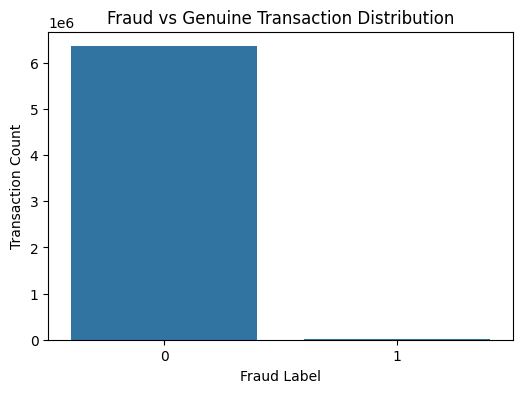

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_upi, x="Fraud_Label")
plt.title("Fraud vs Genuine Transaction Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count")
plt.show()

In [47]:
fraud_summary["Percentage"] = fraud_summary["Percentage"].round(4)

fraud_summary

,Count,Percentage
Genuine,6354407,99.8709
Fraud,8213,0.1291


In [ ]:
## Fraud Imbalance Observation

The dataset is highly imbalanced.

- Genuine transactions are extremely high compared to fraud transactions.
- Fraud transactions represent a very small percentage of the total dataset.
- Because of this imbalance, accuracy alone is not a reliable metric.
- For this project, Recall, Precision, F1 Score, PR-AUC, ROC-AUC, False Negative Rate, and Cost-Based Evaluation will be more important.

In [48]:
fraud_summary.to_csv("data/fraud_imbalance_summary.csv")

In [49]:
import os

os.listdir("data")

['fraud_imbalance_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_raw.csv']

In [50]:
type_count = df_upi["Transaction_Type"].value_counts()
type_count

Transaction_Type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [51]:
type_fraud_count = pd.crosstab(
    df_upi["Transaction_Type"],
    df_upi["Fraud_Label"]
)

type_fraud_count

Fraud_Label,0,1
Transaction_Type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [52]:
type_fraud_count.columns = ["Genuine_Count", "Fraud_Count"]

type_fraud_count

,Genuine_Count,Fraud_Count
Transaction_Type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [53]:
type_fraud_count["Total_Transactions"] = (
    type_fraud_count["Genuine_Count"] + type_fraud_count["Fraud_Count"]
)

type_fraud_count

,Genuine_Count,Fraud_Count,Total_Transactions
Transaction_Type,,,
CASH_IN,1399284,0,1399284
CASH_OUT,2233384,4116,2237500
DEBIT,41432,0,41432
PAYMENT,2151495,0,2151495
TRANSFER,528812,4097,532909


In [54]:
type_fraud_count["Fraud_Percentage"] = (
    type_fraud_count["Fraud_Count"] / type_fraud_count["Total_Transactions"] * 100
)

type_fraud_count["Fraud_Percentage"] = type_fraud_count["Fraud_Percentage"].round(4)

type_fraud_count

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Transaction_Type,,,,
CASH_IN,1399284,0,1399284,0.0000
CASH_OUT,2233384,4116,2237500,0.1840
DEBIT,41432,0,41432,0.0000
PAYMENT,2151495,0,2151495,0.0000
TRANSFER,528812,4097,532909,0.7688


In [55]:
type_fraud_count.sort_values(by="Fraud_Count", ascending=False)

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Transaction_Type,,,,
CASH_OUT,2233384,4116,2237500,0.1840
TRANSFER,528812,4097,532909,0.7688
CASH_IN,1399284,0,1399284,0.0000
DEBIT,41432,0,41432,0.0000
PAYMENT,2151495,0,2151495,0.0000


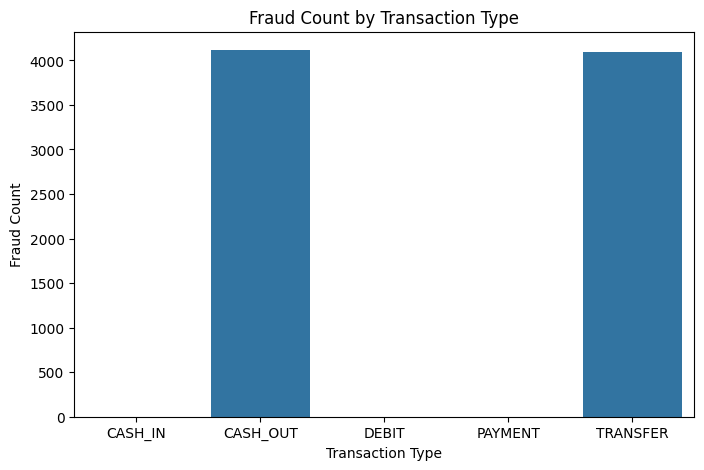

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=type_fraud_count.index,
    y=type_fraud_count["Fraud_Count"]
)
plt.title("Fraud Count by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")
plt.show()

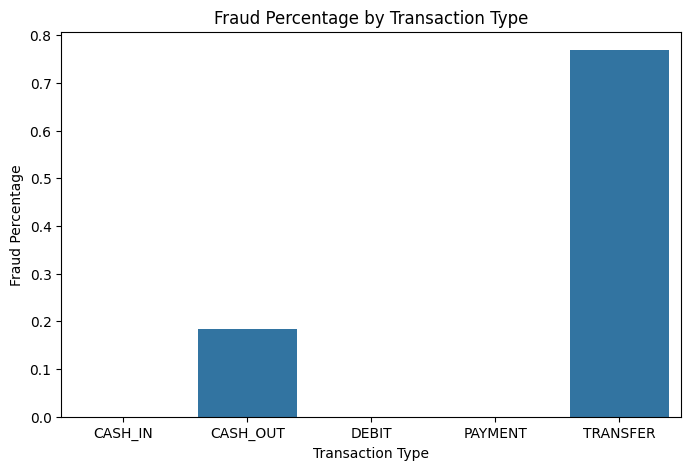

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=type_fraud_count.index,
    y=type_fraud_count["Fraud_Percentage"]
)
plt.title("Fraud Percentage by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Percentage")
plt.show()

In [58]:
type_fraud_count.to_csv("data/transaction_type_fraud_summary.csv")

In [59]:
import os

os.listdir("data")

['fraud_imbalance_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Transaction Type Fraud Observation

Fraud transactions are not equally distributed across all transaction types.

The transaction type analysis helps identify which payment modes are more fraud-prone. This is important because transaction type can become a strong feature for fraud classification and mule-risk detection.

In this dataset, fraud is expected to appear mainly in transfer-related transaction types, which will help build fraud-risk rules and transaction-level risk features.

In [60]:
df_upi["Transaction_Amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: Transaction_Amount, dtype: float64

In [61]:
amount_by_fraud = df_upi.groupby("Fraud_Label")["Transaction_Amount"].describe()

amount_by_fraud

,count,mean,std,min,25%,50%,75%,max
Fraud_Label,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [62]:
amount_by_fraud.index = ["Genuine", "Fraud"]

amount_by_fraud

,count,mean,std,min,25%,50%,75%,max
Genuine,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
Fraud,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [63]:
avg_amount = df_upi.groupby("Fraud_Label")["Transaction_Amount"].mean()

avg_amount

Fraud_Label
0    1.781970e+05
1    1.467967e+06
Name: Transaction_Amount, dtype: float64

In [64]:
median_amount = df_upi.groupby("Fraud_Label")["Transaction_Amount"].median()

median_amount

Fraud_Label
0     74684.72
1    441423.44
Name: Transaction_Amount, dtype: float64

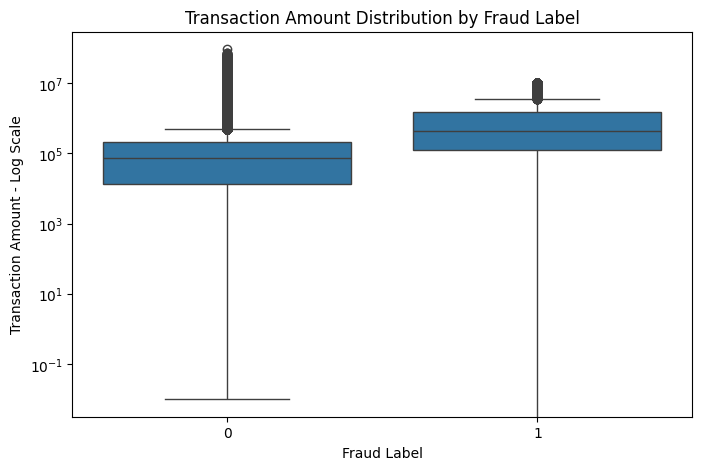

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_upi, x="Fraud_Label", y="Transaction_Amount")
plt.yscale("log")
plt.title("Transaction Amount Distribution by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Amount - Log Scale")
plt.show()

In [66]:
df_upi["Amount_Risk_Bucket"] = pd.qcut(
    df_upi["Transaction_Amount"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

df_upi[["Transaction_Amount", "Amount_Risk_Bucket"]].head()

,Transaction_Amount,Amount_Risk_Bucket
0,9839.64,Very Low
1,1864.28,Very Low
2,181.00,Very Low
3,181.00,Very Low
4,11668.14,Low


In [67]:
amount_bucket_fraud = pd.crosstab(
    df_upi["Amount_Risk_Bucket"],
    df_upi["Fraud_Label"]
)

amount_bucket_fraud.columns = ["Genuine_Count", "Fraud_Count"]

amount_bucket_fraud["Total_Transactions"] = (
    amount_bucket_fraud["Genuine_Count"] + amount_bucket_fraud["Fraud_Count"]
)

amount_bucket_fraud["Fraud_Percentage"] = (
    amount_bucket_fraud["Fraud_Count"] / amount_bucket_fraud["Total_Transactions"] * 100
).round(4)

amount_bucket_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Amount_Risk_Bucket,,,,
Very Low,1272248,276,1272524,0.0217
Low,1272011,513,1272524,0.0403
Medium,1271315,1209,1272524,0.0950
High,1271440,1084,1272524,0.0852
Very High,1267393,5131,1272524,0.4032


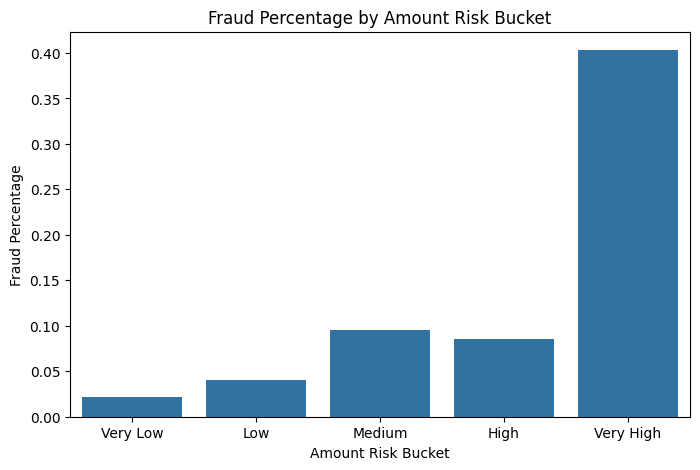

In [68]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=amount_bucket_fraud.index,
    y=amount_bucket_fraud["Fraud_Percentage"]
)
plt.title("Fraud Percentage by Amount Risk Bucket")
plt.xlabel("Amount Risk Bucket")
plt.ylabel("Fraud Percentage")
plt.show()

In [72]:
amount_by_fraud.to_csv("data/amount_by_fraud_summary.csv")
amount_bucket_fraud.to_csv("data/amount_bucket_fraud_summary.csv")

In [70]:
df_upi.to_csv("data/upi_transactions_processed_step2.csv", index=False)

In [71]:
import os

os.listdir("data")

['amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Amount-Based Fraud Observation

Transaction amount is an important fraud-risk signal.

Fraudulent transactions may show different amount patterns compared to genuine transactions. Since transaction amounts can contain extreme values, log-scale visualization is useful for comparing fraud and genuine distributions.

Amount-based risk buckets were created to support future transaction-risk scoring and classification modeling.

In [73]:
hour_fraud = pd.crosstab(
    df_upi["Hour_Of_Day"],
    df_upi["Fraud_Label"]
)

hour_fraud.columns = ["Genuine_Count", "Fraud_Count"]

hour_fraud["Total_Transactions"] = (
    hour_fraud["Genuine_Count"] + hour_fraud["Fraud_Count"]
)

hour_fraud["Fraud_Percentage"] = (
    hour_fraud["Fraud_Count"] / hour_fraud["Total_Transactions"] * 100
).round(4)

hour_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Hour_Of_Day,,,,
0,71287,300,71587,0.4191
1,26753,358,27111,1.3205
2,8646,372,9018,4.1251
3,1681,326,2007,16.2431
4,967,274,1241,22.0790
5,1275,366,1641,22.3035
6,3062,358,3420,10.4678
7,8660,328,8988,3.6493
8,26547,368,26915,1.3673


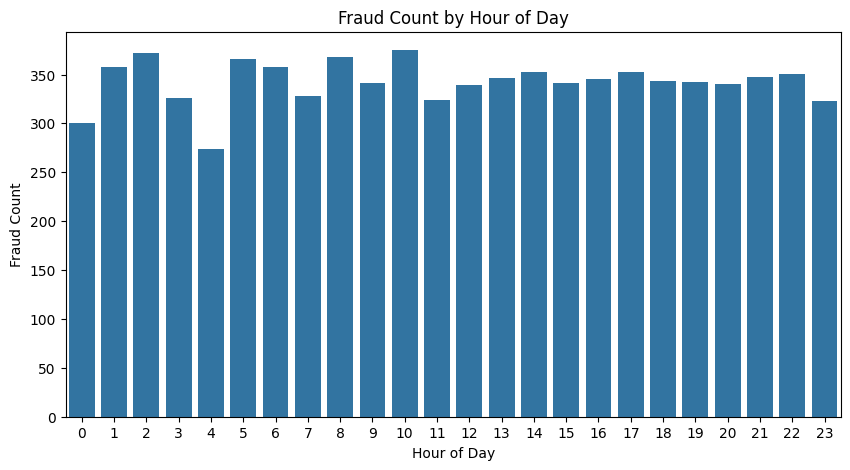

In [74]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=hour_fraud.index,
    y=hour_fraud["Fraud_Count"]
)
plt.title("Fraud Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.show()

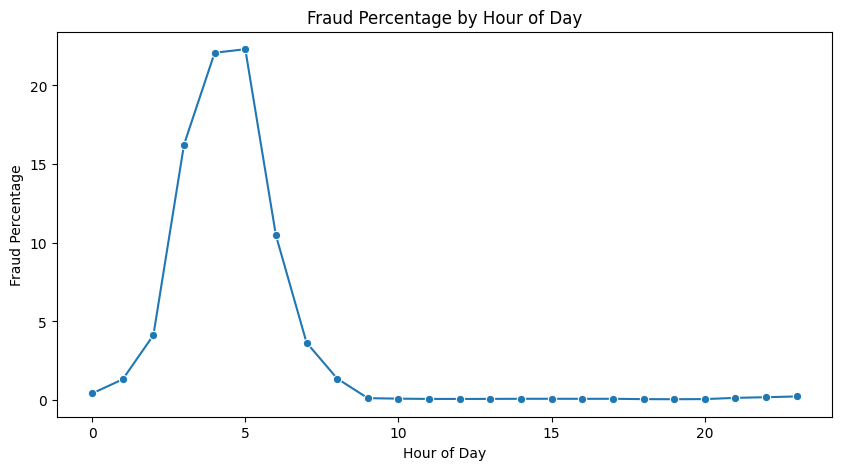

In [75]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x=hour_fraud.index,
    y=hour_fraud["Fraud_Percentage"],
    marker="o"
)
plt.title("Fraud Percentage by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage")
plt.show()

In [76]:
df_upi["Night_Transaction_Flag"] = df_upi["Hour_Of_Day"].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0
)

df_upi[["Hour_Of_Day", "Night_Transaction_Flag"]].head()

,Hour_Of_Day,Night_Transaction_Flag
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [77]:
night_fraud = pd.crosstab(
    df_upi["Night_Transaction_Flag"],
    df_upi["Fraud_Label"]
)

night_fraud.columns = ["Genuine_Count", "Fraud_Count"]

night_fraud["Total_Transactions"] = (
    night_fraud["Genuine_Count"] + night_fraud["Fraud_Count"]
)

night_fraud["Fraud_Percentage"] = (
    night_fraud["Fraud_Count"] / night_fraud["Total_Transactions"] * 100
).round(4)

night_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Night_Transaction_Flag,,,,
0,5908660,5543,5914203,0.0937
1,445747,2670,448417,0.5954


In [78]:
night_fraud.index = ["Day Transaction", "Night Transaction"]

night_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Day Transaction,5908660,5543,5914203,0.0937
Night Transaction,445747,2670,448417,0.5954


In [79]:
day_fraud = pd.crosstab(
    df_upi["Transaction_Day"],
    df_upi["Fraud_Label"]
)

day_fraud.columns = ["Genuine_Count", "Fraud_Count"]

day_fraud["Total_Transactions"] = (
    day_fraud["Genuine_Count"] + day_fraud["Fraud_Count"]
)

day_fraud["Fraud_Percentage"] = (
    day_fraud["Fraud_Count"] / day_fraud["Total_Transactions"] * 100
).round(4)

day_fraud.head()

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Transaction_Day,,,,
1,570774,265,571039,0.0464
2,452456,305,452761,0.0674
3,6443,306,6749,4.5340
4,21632,272,21904,1.2418
5,12751,244,12995,1.8776


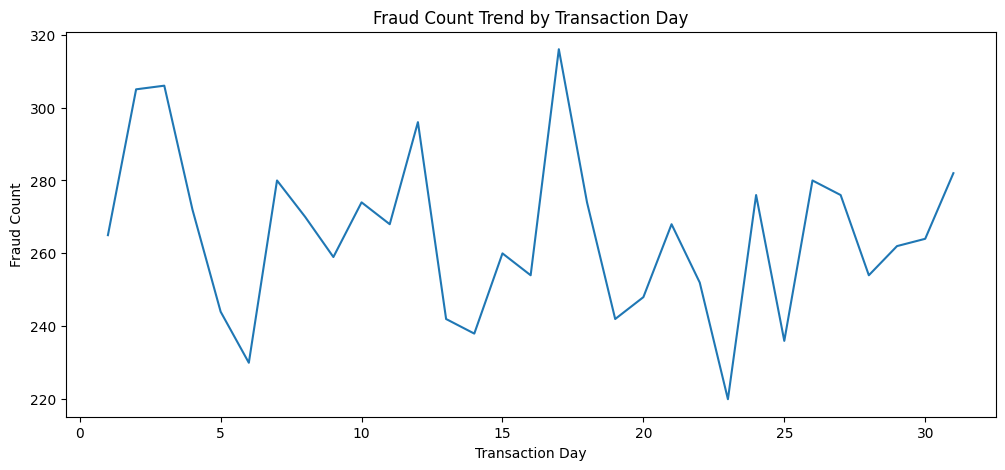

In [80]:
plt.figure(figsize=(12,5))
sns.lineplot(
    x=day_fraud.index,
    y=day_fraud["Fraud_Count"]
)
plt.title("Fraud Count Trend by Transaction Day")
plt.xlabel("Transaction Day")
plt.ylabel("Fraud Count")
plt.show()

In [81]:
hour_fraud.to_csv("data/hour_fraud_summary.csv")
night_fraud.to_csv("data/night_fraud_summary.csv")
day_fraud.to_csv("data/day_fraud_summary.csv")

In [82]:
df_upi.to_csv("data/upi_transactions_processed_step3.csv", index=False)

In [83]:
import os

os.listdir("data")

['amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Time-Based Fraud Observation

Time-based analysis helps identify whether fraudulent transactions are concentrated during specific hours or days.

The `Hour_Of_Day`, `Transaction_Day`, and `Night_Transaction_Flag` features will be useful for building temporal fraud-risk signals.

These features are important for the early-warning system because mule and fraud activity often shows unusual timing and burst behavior.

In [84]:
sender_txn_count = df_upi.groupby("Sender_ID").agg(
    Sender_Total_Transactions=("Transaction_ID", "count"),
    Sender_Total_Amount=("Transaction_Amount", "sum"),
    Sender_Avg_Amount=("Transaction_Amount", "mean"),
    Sender_Max_Amount=("Transaction_Amount", "max"),
    Sender_Fraud_Count=("Fraud_Label", "sum")
).reset_index()

sender_txn_count.head()

,Sender_ID,Sender_Total_Transactions,Sender_Total_Amount,Sender_Avg_Amount,Sender_Max_Amount,Sender_Fraud_Count
0,C1000000639,1,244486.46,244486.46,244486.46,0
1,C1000001337,1,3170.28,3170.28,3170.28,0
2,C1000001725,1,8424.74,8424.74,8424.74,0
3,C1000002591,1,261877.19,261877.19,261877.19,0
4,C1000003372,1,20528.65,20528.65,20528.65,0


In [85]:
sender_txn_count["Sender_Fraud_Percentage"] = (
    sender_txn_count["Sender_Fraud_Count"] / sender_txn_count["Sender_Total_Transactions"] * 100
).round(4)

sender_txn_count.head()

,Sender_ID,Sender_Total_Transactions,Sender_Total_Amount,Sender_Avg_Amount,Sender_Max_Amount,Sender_Fraud_Count,Sender_Fraud_Percentage
0,C1000000639,1,244486.46,244486.46,244486.46,0,0.0
1,C1000001337,1,3170.28,3170.28,3170.28,0,0.0
2,C1000001725,1,8424.74,8424.74,8424.74,0,0.0
3,C1000002591,1,261877.19,261877.19,261877.19,0,0.0
4,C1000003372,1,20528.65,20528.65,20528.65,0,0.0


In [86]:
receiver_txn_count = df_upi.groupby("Receiver_ID").agg(
    Receiver_Total_Transactions=("Transaction_ID", "count"),
    Receiver_Total_Amount=("Transaction_Amount", "sum"),
    Receiver_Avg_Amount=("Transaction_Amount", "mean"),
    Receiver_Max_Amount=("Transaction_Amount", "max"),
    Receiver_Fraud_Count=("Fraud_Label", "sum")
).reset_index()

receiver_txn_count.head()

,Receiver_ID,Receiver_Total_Transactions,Receiver_Total_Amount,Receiver_Avg_Amount,Receiver_Max_Amount,Receiver_Fraud_Count
0,C1000004082,6,2259324.39,376554.065000,1331742.99,0
1,C1000004940,13,2534004.05,194923.388462,556785.00,0
2,C1000013769,13,6204082.94,477237.149231,1606651.99,0
3,C100001587,9,1404313.66,156034.851111,481674.22,0
4,C1000015936,16,2267960.19,141747.511875,241817.38,0


In [87]:
receiver_txn_count["Receiver_Fraud_Percentage"] = (
    receiver_txn_count["Receiver_Fraud_Count"] / receiver_txn_count["Receiver_Total_Transactions"] * 100
).round(4)

receiver_txn_count.head()

,Receiver_ID,Receiver_Total_Transactions,Receiver_Total_Amount,Receiver_Avg_Amount,Receiver_Max_Amount,Receiver_Fraud_Count,Receiver_Fraud_Percentage
0,C1000004082,6,2259324.39,376554.065000,1331742.99,0,0.0
1,C1000004940,13,2534004.05,194923.388462,556785.00,0,0.0
2,C1000013769,13,6204082.94,477237.149231,1606651.99,0,0.0
3,C100001587,9,1404313.66,156034.851111,481674.22,0,0.0
4,C1000015936,16,2267960.19,141747.511875,241817.38,0,0.0


In [88]:
top_fraud_senders = sender_txn_count.sort_values(
    by="Sender_Fraud_Count",
    ascending=False
).head(10)

top_fraud_senders

,Sender_ID,Sender_Total_Transactions,Sender_Total_Amount,Sender_Avg_Amount,Sender_Max_Amount,Sender_Fraud_Count,Sender_Fraud_Percentage
343388,C1104869047,1,1445166.74,1445166.74,1445166.74,1,100.0
2613958,C1795788636,1,662276.78,662276.78,662276.78,1,100.0
1730011,C1526831204,1,234787.38,234787.38,234787.38,1,100.0
941792,C1287154806,1,404185.57,404185.57,404185.57,1,100.0
2137897,C165094398,1,1161495.82,1161495.82,1161495.82,1,100.0
2166075,C1659569966,1,1032168.79,1032168.79,1032168.79,1,100.0
2460798,C17491956,1,2460110.25,2460110.25,2460110.25,1,100.0
2365651,C1720178910,1,6498297.70,6498297.70,6498297.70,1,100.0
2143304,C1652591304,1,5245375.30,5245375.30,5245375.30,1,100.0
953486,C129076810,1,972142.03,972142.03,972142.03,1,100.0


In [89]:
top_fraud_senders = sender_txn_count.sort_values(
    by="Sender_Fraud_Count",
    ascending=False
).head(10)

top_fraud_senders

,Sender_ID,Sender_Total_Transactions,Sender_Total_Amount,Sender_Avg_Amount,Sender_Max_Amount,Sender_Fraud_Count,Sender_Fraud_Percentage
343388,C1104869047,1,1445166.74,1445166.74,1445166.74,1,100.0
2613958,C1795788636,1,662276.78,662276.78,662276.78,1,100.0
1730011,C1526831204,1,234787.38,234787.38,234787.38,1,100.0
941792,C1287154806,1,404185.57,404185.57,404185.57,1,100.0
2137897,C165094398,1,1161495.82,1161495.82,1161495.82,1,100.0
2166075,C1659569966,1,1032168.79,1032168.79,1032168.79,1,100.0
2460798,C17491956,1,2460110.25,2460110.25,2460110.25,1,100.0
2365651,C1720178910,1,6498297.70,6498297.70,6498297.70,1,100.0
2143304,C1652591304,1,5245375.30,5245375.30,5245375.30,1,100.0
953486,C129076810,1,972142.03,972142.03,972142.03,1,100.0


In [90]:
top_fraud_receivers = receiver_txn_count.sort_values(
    by="Receiver_Fraud_Count",
    ascending=False
).head(10)

top_fraud_receivers

,Receiver_ID,Receiver_Total_Transactions,Receiver_Total_Amount,Receiver_Avg_Amount,Receiver_Max_Amount,Receiver_Fraud_Count,Receiver_Fraud_Percentage
4005,C1013511446,35,22226171.13,635033.460857,2657484.81,2,5.7143
57504,C1193568854,37,10871154.95,293814.998649,2355287.99,2,5.4054
192625,C1650668671,4,179243.16,44810.790000,106471.33,2,50.0000
253941,C185805228,47,13847068.93,294618.487872,2594904.29,2,4.2553
296180,C200064275,33,6601096.88,200033.238788,895351.60,2,6.0606
466269,C643624257,17,5912357.32,347785.724706,2374490.77,2,11.7647
118434,C1399829166,25,9831277.06,393251.082400,2984434.36,2,8.0000
55009,C1185292292,6,851350.93,141891.821667,215299.28,2,33.3333
16764,C105660024,15,3094694.86,206312.990667,505761.68,2,13.3333
247794,C1837027614,2,951189.90,475594.950000,517183.38,2,100.0000


In [91]:
sender_txn_count["Sender_Total_Transactions"].describe()

count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: Sender_Total_Transactions, dtype: float64

In [92]:
receiver_txn_count["Receiver_Total_Transactions"].describe()

count    2.722362e+06
mean     2.337169e+00
std      4.549264e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.130000e+02
Name: Receiver_Total_Transactions, dtype: float64

In [93]:
sender_txn_count.to_csv("data/sender_account_summary.csv", index=False)
receiver_txn_count.to_csv("data/receiver_account_summary.csv", index=False)
top_fraud_senders.to_csv("data/top_fraud_senders.csv", index=False)
top_fraud_receivers.to_csv("data/top_fraud_receivers.csv", index=False)

In [94]:
import os

os.listdir("data")

['amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Account-Level Fraud Observation

Account-level analysis is important for detecting mule behavior.

Instead of analyzing only individual transactions, this step aggregates sender and receiver behavior to identify accounts with suspicious transaction volume, high transaction amounts, and fraud involvement.

These account-level features will later help create mule-risk scores, receiver-network risk, and investigation priority ranking.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_upi = pd.read_csv("data/upi_transactions_processed_step3.csv")

df_upi.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,Fraud_Label,System_Flagged_Fraud,Transaction_Day,Hour_Of_Day,Amount_Risk_Bucket,Night_Transaction_Flag
0,1,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,1,Very Low,1
1,2,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,1,Very Low,1
2,3,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,1,Very Low,1
3,4,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,1,Very Low,1
4,5,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,1,Low,1


In [2]:
df_upi.shape

(6362620, 16)

In [3]:
sender_features = df_upi.groupby("Sender_ID").agg(
    Outgoing_Transaction_Count=("Transaction_ID", "count"),
    Outgoing_Total_Amount=("Transaction_Amount", "sum"),
    Outgoing_Avg_Amount=("Transaction_Amount", "mean"),
    Outgoing_Max_Amount=("Transaction_Amount", "max"),
    Fraud_Outgoing_Count=("Fraud_Label", "sum"),
    Unique_Receivers=("Receiver_ID", "nunique")
).reset_index()

sender_features = sender_features.rename(columns={"Sender_ID": "Account_ID"})

sender_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers
0,C1000000639,1,244486.46,244486.46,244486.46,0,1
1,C1000001337,1,3170.28,3170.28,3170.28,0,1
2,C1000001725,1,8424.74,8424.74,8424.74,0,1
3,C1000002591,1,261877.19,261877.19,261877.19,0,1
4,C1000003372,1,20528.65,20528.65,20528.65,0,1


In [4]:
receiver_features = df_upi.groupby("Receiver_ID").agg(
    Incoming_Transaction_Count=("Transaction_ID", "count"),
    Incoming_Total_Amount=("Transaction_Amount", "sum"),
    Incoming_Avg_Amount=("Transaction_Amount", "mean"),
    Incoming_Max_Amount=("Transaction_Amount", "max"),
    Fraud_Incoming_Count=("Fraud_Label", "sum"),
    Unique_Senders=("Sender_ID", "nunique")
).reset_index()

receiver_features = receiver_features.rename(columns={"Receiver_ID": "Account_ID"})

receiver_features.head()

,Account_ID,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders
0,C1000004082,6,2259324.39,376554.065000,1331742.99,0,6
1,C1000004940,13,2534004.05,194923.388462,556785.00,0,13
2,C1000013769,13,6204082.94,477237.149231,1606651.99,0,13
3,C100001587,9,1404313.66,156034.851111,481674.22,0,9
4,C1000015936,16,2267960.19,141747.511875,241817.38,0,16


In [5]:
account_features = pd.merge(
    sender_features,
    receiver_features,
    on="Account_ID",
    how="outer"
)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
account_features = account_features.fillna(0)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
account_features["Pass_Through_Ratio"] = (
    account_features["Outgoing_Total_Amount"] / 
    (account_features["Incoming_Total_Amount"] + 1)
)

account_features["Pass_Through_Ratio"] = account_features["Pass_Through_Ratio"].round(4)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,244486.46
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3170.28
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8424.74
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,261877.19
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20528.65


In [8]:
account_features["In_Out_Transaction_Ratio"] = (
    account_features["Incoming_Transaction_Count"] / 
    (account_features["Outgoing_Transaction_Count"] + 1)
)

account_features["In_Out_Transaction_Ratio"] = account_features["In_Out_Transaction_Ratio"].round(4)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio,In_Out_Transaction_Ratio
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,244486.46,0.0
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3170.28,0.0
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8424.74,0.0
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,261877.19,0.0
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20528.65,0.0


In [9]:
account_features["Total_Transaction_Count"] = (
    account_features["Incoming_Transaction_Count"] + 
    account_features["Outgoing_Transaction_Count"]
)

account_features["Total_Transaction_Amount"] = (
    account_features["Incoming_Total_Amount"] + 
    account_features["Outgoing_Total_Amount"]
)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio,In_Out_Transaction_Ratio,Total_Transaction_Count,Total_Transaction_Amount
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,244486.46,0.0,1.0,244486.46
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3170.28,0.0,1.0,3170.28
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8424.74,0.0,1.0,8424.74
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,261877.19,0.0,1.0,261877.19
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20528.65,0.0,1.0,20528.65


In [10]:
account_features["Total_Fraud_Count"] = (
    account_features["Fraud_Incoming_Count"] + 
    account_features["Fraud_Outgoing_Count"]
)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio,In_Out_Transaction_Ratio,Total_Transaction_Count,Total_Transaction_Amount,Total_Fraud_Count
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,244486.46,0.0,1.0,244486.46,0.0
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3170.28,0.0,1.0,3170.28,0.0
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8424.74,0.0,1.0,8424.74,0.0
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,261877.19,0.0,1.0,261877.19,0.0
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20528.65,0.0,1.0,20528.65,0.0


In [11]:
account_features["Fraud_Involved_Flag"] = account_features["Total_Fraud_Count"].apply(
    lambda x: 1 if x > 0 else 0
)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio,In_Out_Transaction_Ratio,Total_Transaction_Count,Total_Transaction_Amount,Total_Fraud_Count,Fraud_Involved_Flag
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,244486.46,0.0,1.0,244486.46,0.0,0
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3170.28,0.0,1.0,3170.28,0.0,0
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8424.74,0.0,1.0,8424.74,0.0,0
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,261877.19,0.0,1.0,261877.19,0.0,0
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20528.65,0.0,1.0,20528.65,0.0,0


In [12]:
account_features["Mule_Risk_Score"] = (
    (account_features["Pass_Through_Ratio"] > 0.8).astype(int) * 25 +
    (account_features["Unique_Senders"] >= 3).astype(int) * 15 +
    (account_features["Unique_Receivers"] >= 3).astype(int) * 15 +
    (account_features["Total_Transaction_Count"] >= 5).astype(int) * 15 +
    (account_features["Total_Fraud_Count"] > 0).astype(int) * 30
)

account_features.head()

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,Incoming_Max_Amount,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio,In_Out_Transaction_Ratio,Total_Transaction_Count,Total_Transaction_Amount,Total_Fraud_Count,Fraud_Involved_Flag,Mule_Risk_Score
0,C1000000639,1.0,244486.46,244486.46,244486.46,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,244486.46,0.0,1.0,244486.46,0.0,0,25
1,C1000001337,1.0,3170.28,3170.28,3170.28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3170.28,0.0,1.0,3170.28,0.0,0,25
2,C1000001725,1.0,8424.74,8424.74,8424.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8424.74,0.0,1.0,8424.74,0.0,0,25
3,C1000002591,1.0,261877.19,261877.19,261877.19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,261877.19,0.0,1.0,261877.19,0.0,0,25
4,C1000003372,1.0,20528.65,20528.65,20528.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20528.65,0.0,1.0,20528.65,0.0,0,25


In [13]:
def assign_account_risk(score):
    if score >= 70:
        return "Critical Mule Risk"
    elif score >= 45:
        return "High Mule Risk"
    elif score >= 20:
        return "Low Mule Risk"
    else:
        return "Normal Account"

account_features["Account_Risk_Level"] = account_features["Mule_Risk_Score"].apply(assign_account_risk)

account_features["Account_Risk_Level"].value_counts()

Account_Risk_Level
Low Mule Risk     6623391
Normal Account    2437541
High Mule Risk      12968
Name: count, dtype: int64

In [14]:
top_mule_risk_accounts = account_features.sort_values(
    by="Mule_Risk_Score",
    ascending=False
).head(20)

top_mule_risk_accounts

,Account_ID,Outgoing_Transaction_Count,Outgoing_Total_Amount,Outgoing_Avg_Amount,Outgoing_Max_Amount,Fraud_Outgoing_Count,Unique_Receivers,Incoming_Transaction_Count,Incoming_Total_Amount,Incoming_Avg_Amount,...,Fraud_Incoming_Count,Unique_Senders,Pass_Through_Ratio,In_Out_Transaction_Ratio,Total_Transaction_Count,Total_Transaction_Amount,Total_Fraud_Count,Fraud_Involved_Flag,Mule_Risk_Score,Account_Risk_Level
356387,C109980101,0.0,0.0,0.0,0.0,0.0,0.0,26.0,8047283.33,3.095109e+05,...,1.0,26.0,0.0,26.0,26.0,8047283.33,1.0,1,60,High Mule Risk
2981066,C1832609455,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1479089.77,2.112985e+05,...,1.0,7.0,0.0,7.0,7.0,1479089.77,1.0,1,60,High Mule Risk
1962777,C1548348754,0.0,0.0,0.0,0.0,0.0,0.0,36.0,12672920.38,3.520256e+05,...,1.0,36.0,0.0,36.0,36.0,12672920.38,1.0,1,60,High Mule Risk
1094353,C1306048259,0.0,0.0,0.0,0.0,0.0,0.0,12.0,2452777.79,2.043981e+05,...,1.0,12.0,0.0,12.0,12.0,2452777.79,1.0,1,60,High Mule Risk
302976,C1084850642,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1579828.40,2.256898e+05,...,1.0,7.0,0.0,7.0,7.0,1579828.40,1.0,1,60,High Mule Risk
2018560,C1564045599,0.0,0.0,0.0,0.0,0.0,0.0,40.0,10458169.89,2.614542e+05,...,1.0,40.0,0.0,40.0,40.0,10458169.89,1.0,1,60,High Mule Risk
2347988,C1656002474,0.0,0.0,0.0,0.0,0.0,0.0,6.0,686598.84,1.144331e+05,...,1.0,6.0,0.0,6.0,6.0,686598.84,1.0,1,60,High Mule Risk
3828153,C2068912679,0.0,0.0,0.0,0.0,0.0,0.0,8.0,9625417.25,1.203177e+06,...,1.0,8.0,0.0,8.0,8.0,9625417.25,1.0,1,60,High Mule Risk
3827896,C2068840304,0.0,0.0,0.0,0.0,0.0,0.0,5.0,1179058.52,2.358117e+05,...,1.0,5.0,0.0,5.0,5.0,1179058.52,1.0,1,60,High Mule Risk
2275155,C1635587214,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1356886.21,1.938409e+05,...,1.0,7.0,0.0,7.0,7.0,1356886.21,1.0,1,60,High Mule Risk


In [15]:
account_features.to_csv("data/account_mule_risk_features.csv", index=False)
top_mule_risk_accounts.to_csv("data/top_mule_risk_accounts.csv", index=False)

In [16]:
import os

os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Mule-Risk Account Feature Engineering

Account-level mule-risk features were created by combining sender and receiver behavior.

Important features include:

- Incoming transaction count
- Outgoing transaction count
- Unique senders
- Unique receivers
- Pass-through ratio
- In-out transaction ratio
- Total fraud involvement
- Mule risk score
- Account risk level

These features help move the project from simple transaction fraud detection to account-level mule-risk intelligence.

In [17]:
account_features.shape

(9073900, 21)

In [18]:
account_features["Account_Risk_Level"].value_counts()

Account_Risk_Level
Low Mule Risk     6623391
Normal Account    2437541
High Mule Risk      12968
Name: count, dtype: int64

In [19]:
account_risk_selected = account_features[
    [
        "Account_ID",
        "Mule_Risk_Score",
        "Account_Risk_Level",
        "Pass_Through_Ratio",
        "In_Out_Transaction_Ratio",
        "Total_Transaction_Count",
        "Total_Transaction_Amount",
        "Total_Fraud_Count",
        "Fraud_Involved_Flag",
        "Unique_Senders",
        "Unique_Receivers"
    ]
]

account_risk_selected.head()

,Account_ID,Mule_Risk_Score,Account_Risk_Level,Pass_Through_Ratio,In_Out_Transaction_Ratio,Total_Transaction_Count,Total_Transaction_Amount,Total_Fraud_Count,Fraud_Involved_Flag,Unique_Senders,Unique_Receivers
0,C1000000639,25,Low Mule Risk,244486.46,0.0,1.0,244486.46,0.0,0,0.0,1.0
1,C1000001337,25,Low Mule Risk,3170.28,0.0,1.0,3170.28,0.0,0,0.0,1.0
2,C1000001725,25,Low Mule Risk,8424.74,0.0,1.0,8424.74,0.0,0,0.0,1.0
3,C1000002591,25,Low Mule Risk,261877.19,0.0,1.0,261877.19,0.0,0,0.0,1.0
4,C1000003372,25,Low Mule Risk,20528.65,0.0,1.0,20528.65,0.0,0,0.0,1.0


In [20]:
sender_risk = account_risk_selected.rename(columns={
    "Account_ID": "Sender_ID",
    "Mule_Risk_Score": "Sender_Mule_Risk_Score",
    "Account_Risk_Level": "Sender_Account_Risk_Level",
    "Pass_Through_Ratio": "Sender_Pass_Through_Ratio",
    "In_Out_Transaction_Ratio": "Sender_In_Out_Transaction_Ratio",
    "Total_Transaction_Count": "Sender_Total_Transaction_Count",
    "Total_Transaction_Amount": "Sender_Total_Transaction_Amount",
    "Total_Fraud_Count": "Sender_Total_Fraud_Count",
    "Fraud_Involved_Flag": "Sender_Fraud_Involved_Flag",
    "Unique_Senders": "Sender_Unique_Senders",
    "Unique_Receivers": "Sender_Unique_Receivers"
})

sender_risk.head()

,Sender_ID,Sender_Mule_Risk_Score,Sender_Account_Risk_Level,Sender_Pass_Through_Ratio,Sender_In_Out_Transaction_Ratio,Sender_Total_Transaction_Count,Sender_Total_Transaction_Amount,Sender_Total_Fraud_Count,Sender_Fraud_Involved_Flag,Sender_Unique_Senders,Sender_Unique_Receivers
0,C1000000639,25,Low Mule Risk,244486.46,0.0,1.0,244486.46,0.0,0,0.0,1.0
1,C1000001337,25,Low Mule Risk,3170.28,0.0,1.0,3170.28,0.0,0,0.0,1.0
2,C1000001725,25,Low Mule Risk,8424.74,0.0,1.0,8424.74,0.0,0,0.0,1.0
3,C1000002591,25,Low Mule Risk,261877.19,0.0,1.0,261877.19,0.0,0,0.0,1.0
4,C1000003372,25,Low Mule Risk,20528.65,0.0,1.0,20528.65,0.0,0,0.0,1.0


In [21]:
receiver_risk = account_risk_selected.rename(columns={
    "Account_ID": "Receiver_ID",
    "Mule_Risk_Score": "Receiver_Mule_Risk_Score",
    "Account_Risk_Level": "Receiver_Account_Risk_Level",
    "Pass_Through_Ratio": "Receiver_Pass_Through_Ratio",
    "In_Out_Transaction_Ratio": "Receiver_In_Out_Transaction_Ratio",
    "Total_Transaction_Count": "Receiver_Total_Transaction_Count",
    "Total_Transaction_Amount": "Receiver_Total_Transaction_Amount",
    "Total_Fraud_Count": "Receiver_Total_Fraud_Count",
    "Fraud_Involved_Flag": "Receiver_Fraud_Involved_Flag",
    "Unique_Senders": "Receiver_Unique_Senders",
    "Unique_Receivers": "Receiver_Unique_Receivers"
})

receiver_risk.head()

,Receiver_ID,Receiver_Mule_Risk_Score,Receiver_Account_Risk_Level,Receiver_Pass_Through_Ratio,Receiver_In_Out_Transaction_Ratio,Receiver_Total_Transaction_Count,Receiver_Total_Transaction_Amount,Receiver_Total_Fraud_Count,Receiver_Fraud_Involved_Flag,Receiver_Unique_Senders,Receiver_Unique_Receivers
0,C1000000639,25,Low Mule Risk,244486.46,0.0,1.0,244486.46,0.0,0,0.0,1.0
1,C1000001337,25,Low Mule Risk,3170.28,0.0,1.0,3170.28,0.0,0,0.0,1.0
2,C1000001725,25,Low Mule Risk,8424.74,0.0,1.0,8424.74,0.0,0,0.0,1.0
3,C1000002591,25,Low Mule Risk,261877.19,0.0,1.0,261877.19,0.0,0,0.0,1.0
4,C1000003372,25,Low Mule Risk,20528.65,0.0,1.0,20528.65,0.0,0,0.0,1.0


In [22]:
df_model = df_upi.merge(
    sender_risk,
    on="Sender_ID",
    how="left"
)

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Sender_Mule_Risk_Score,Sender_Account_Risk_Level,Sender_Pass_Through_Ratio,Sender_In_Out_Transaction_Ratio,Sender_Total_Transaction_Count,Sender_Total_Transaction_Amount,Sender_Total_Fraud_Count,Sender_Fraud_Involved_Flag,Sender_Unique_Senders,Sender_Unique_Receivers
0,1,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,...,25,Low Mule Risk,9839.64,0.0,1.0,9839.64,0.0,0,0.0,1.0
1,2,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,...,25,Low Mule Risk,1864.28,0.0,1.0,1864.28,0.0,0,0.0,1.0
2,3,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,...,55,High Mule Risk,181.00,0.0,1.0,181.00,1.0,1,0.0,1.0
3,4,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,...,55,High Mule Risk,181.00,0.0,1.0,181.00,1.0,1,0.0,1.0
4,5,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,...,25,Low Mule Risk,11668.14,0.0,1.0,11668.14,0.0,0,0.0,1.0


In [24]:
import gc

try:
    del df_model
except:
    pass

gc.collect()

2523

In [26]:
import gc

for var in ["df_model", "account_lookup", "sender_risk", "receiver_risk", "account_risk_selected"]:
    try:
        del globals()[var]
    except:
        pass

gc.collect()

2257

In [27]:
fraud_df = df_upi[df_upi["Fraud_Label"] == 1]

genuine_df = df_upi[df_upi["Fraud_Label"] == 0].sample(
    n=500000,
    random_state=42
)

df_model = pd.concat([fraud_df, genuine_df], axis=0).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_model.shape

(508213, 16)

In [28]:
needed_accounts = set(df_model["Sender_ID"]).union(set(df_model["Receiver_ID"]))

len(needed_accounts)

891193

In [29]:
account_features_small = account_features[
    account_features["Account_ID"].isin(needed_accounts)
].copy()

account_features_small.shape

(891193, 21)

In [30]:
account_lookup = account_features_small.set_index("Account_ID")

account_lookup.shape

(891193, 20)

In [31]:
df_model["Sender_Mule_Risk_Score"] = df_model["Sender_ID"].map(account_lookup["Mule_Risk_Score"])
df_model["Sender_Account_Risk_Level"] = df_model["Sender_ID"].map(account_lookup["Account_Risk_Level"])
df_model["Sender_Pass_Through_Ratio"] = df_model["Sender_ID"].map(account_lookup["Pass_Through_Ratio"])
df_model["Sender_In_Out_Transaction_Ratio"] = df_model["Sender_ID"].map(account_lookup["In_Out_Transaction_Ratio"])
df_model["Sender_Total_Transaction_Count"] = df_model["Sender_ID"].map(account_lookup["Total_Transaction_Count"])
df_model["Sender_Total_Fraud_Count"] = df_model["Sender_ID"].map(account_lookup["Total_Fraud_Count"])
df_model["Sender_Fraud_Involved_Flag"] = df_model["Sender_ID"].map(account_lookup["Fraud_Involved_Flag"])
df_model["Sender_Unique_Receivers"] = df_model["Sender_ID"].map(account_lookup["Unique_Receivers"])

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Amount_Risk_Bucket,Night_Transaction_Flag,Sender_Mule_Risk_Score,Sender_Account_Risk_Level,Sender_Pass_Through_Ratio,Sender_In_Out_Transaction_Ratio,Sender_Total_Transaction_Count,Sender_Total_Fraud_Count,Sender_Fraud_Involved_Flag,Sender_Unique_Receivers
0,1276960,135,CASH_IN,15357.93,C1517416764,7153299.72,7168657.65,C300630516,2984106.26,2968748.32,...,Low,0,25,Low Mule Risk,15357.93,0.0,1.0,0.0,0,1.0
1,2908635,228,CASH_IN,14233.75,C476259998,4002084.44,4016318.19,C376141086,1005161.64,990927.89,...,Low,0,25,Low Mule Risk,14233.75,0.0,1.0,0.0,0,1.0
2,5436546,378,TRANSFER,98633.36,C910672370,52458.00,0.00,C1782359566,2381916.08,2480549.44,...,Medium,0,25,Low Mule Risk,98633.36,0.0,1.0,0.0,0,1.0
3,784653,39,PAYMENT,7942.91,C787203864,18623.00,10680.09,M64645135,0.00,0.00,...,Very Low,0,25,Low Mule Risk,7942.91,0.0,1.0,0.0,0,1.0
4,3414499,256,CASH_OUT,94081.56,C336439060,0.00,0.00,C23916296,476054.15,570135.71,...,Medium,0,25,Low Mule Risk,94081.56,0.0,1.0,0.0,0,1.0


In [32]:
df_model["Receiver_Mule_Risk_Score"] = df_model["Receiver_ID"].map(account_lookup["Mule_Risk_Score"])
df_model["Receiver_Account_Risk_Level"] = df_model["Receiver_ID"].map(account_lookup["Account_Risk_Level"])
df_model["Receiver_Pass_Through_Ratio"] = df_model["Receiver_ID"].map(account_lookup["Pass_Through_Ratio"])
df_model["Receiver_In_Out_Transaction_Ratio"] = df_model["Receiver_ID"].map(account_lookup["In_Out_Transaction_Ratio"])
df_model["Receiver_Total_Transaction_Count"] = df_model["Receiver_ID"].map(account_lookup["Total_Transaction_Count"])
df_model["Receiver_Total_Fraud_Count"] = df_model["Receiver_ID"].map(account_lookup["Total_Fraud_Count"])
df_model["Receiver_Fraud_Involved_Flag"] = df_model["Receiver_ID"].map(account_lookup["Fraud_Involved_Flag"])
df_model["Receiver_Unique_Senders"] = df_model["Receiver_ID"].map(account_lookup["Unique_Senders"])

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Sender_Fraud_Involved_Flag,Sender_Unique_Receivers,Receiver_Mule_Risk_Score,Receiver_Account_Risk_Level,Receiver_Pass_Through_Ratio,Receiver_In_Out_Transaction_Ratio,Receiver_Total_Transaction_Count,Receiver_Total_Fraud_Count,Receiver_Fraud_Involved_Flag,Receiver_Unique_Senders
0,1276960,135,CASH_IN,15357.93,C1517416764,7153299.72,7168657.65,C300630516,2984106.26,2968748.32,...,0,1.0,30,Low Mule Risk,0.0,30.0,30.0,0.0,0,30.0
1,2908635,228,CASH_IN,14233.75,C476259998,4002084.44,4016318.19,C376141086,1005161.64,990927.89,...,0,1.0,30,Low Mule Risk,0.0,25.0,25.0,0.0,0,25.0
2,5436546,378,TRANSFER,98633.36,C910672370,52458.00,0.00,C1782359566,2381916.08,2480549.44,...,0,1.0,30,Low Mule Risk,0.0,25.0,25.0,0.0,0,25.0
3,784653,39,PAYMENT,7942.91,C787203864,18623.00,10680.09,M64645135,0.00,0.00,...,0,1.0,0,Normal Account,0.0,1.0,1.0,0.0,0,1.0
4,3414499,256,CASH_OUT,94081.56,C336439060,0.00,0.00,C23916296,476054.15,570135.71,...,0,1.0,30,Low Mule Risk,0.0,14.0,14.0,0.0,0,14.0


In [33]:
df_model.shape

(508213, 32)

In [34]:
numeric_cols_to_fill = [
    "Sender_Mule_Risk_Score",
    "Sender_Pass_Through_Ratio",
    "Sender_In_Out_Transaction_Ratio",
    "Sender_Total_Transaction_Count",
    "Sender_Total_Fraud_Count",
    "Sender_Fraud_Involved_Flag",
    "Sender_Unique_Receivers",
    "Receiver_Mule_Risk_Score",
    "Receiver_Pass_Through_Ratio",
    "Receiver_In_Out_Transaction_Ratio",
    "Receiver_Total_Transaction_Count",
    "Receiver_Total_Fraud_Count",
    "Receiver_Fraud_Involved_Flag",
    "Receiver_Unique_Senders"
]

df_model[numeric_cols_to_fill] = df_model[numeric_cols_to_fill].fillna(0)

df_model["Sender_Account_Risk_Level"] = df_model["Sender_Account_Risk_Level"].fillna("Unknown")
df_model["Receiver_Account_Risk_Level"] = df_model["Receiver_Account_Risk_Level"].fillna("Unknown")

In [35]:
df_model[
    [
        "Sender_Mule_Risk_Score",
        "Receiver_Mule_Risk_Score",
        "Sender_Account_Risk_Level",
        "Receiver_Account_Risk_Level"
    ]
].isnull().sum()

Sender_Mule_Risk_Score         0
Receiver_Mule_Risk_Score       0
Sender_Account_Risk_Level      0
Receiver_Account_Risk_Level    0
dtype: int64

In [36]:
df_model["Sender_Account_Risk_Level"].value_counts()

Sender_Account_Risk_Level
Low Mule Risk     499961
High Mule Risk      8205
Normal Account        47
Name: count, dtype: int64

In [37]:
df_model["Receiver_Account_Risk_Level"].value_counts()

Receiver_Account_Risk_Level
Low Mule Risk     282393
Normal Account    216554
High Mule Risk      9266
Name: count, dtype: int64

In [38]:
df_model.to_csv("data/model_dataset_account_risk_sample.csv", index=False)

In [39]:
import os

os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_dataset_account_risk_sample.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Account Risk Feature Merge

Account-level mule-risk features were merged into the fraud-aware transaction sample.

The model dataset contains all fraud transactions and a sample of genuine transactions to support memory-efficient modeling.

Each transaction now includes sender and receiver risk signals such as:

- Mule risk score
- Account risk level
- Pass-through ratio
- In-out transaction ratio
- Fraud involvement flag
- Unique sender/receiver behavior

This creates a stronger model-ready dataset for fraud and mule-risk classification.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_model = pd.read_csv("data/model_dataset_account_risk_sample.csv")

df_model.shape

(508213, 32)

In [41]:
df_model["Sender_Balance_Error"] = (
    df_model["Sender_Old_Balance"] -
    df_model["Transaction_Amount"] -
    df_model["Sender_New_Balance"]
)

df_model[["Sender_Old_Balance", "Transaction_Amount", "Sender_New_Balance", "Sender_Balance_Error"]].head()

,Sender_Old_Balance,Transaction_Amount,Sender_New_Balance,Sender_Balance_Error
0,7153299.72,15357.93,7168657.65,-30715.86
1,4002084.44,14233.75,4016318.19,-28467.50
2,52458.00,98633.36,0.00,-46175.36
3,18623.00,7942.91,10680.09,0.00
4,0.00,94081.56,0.00,-94081.56


In [42]:
df_model["Receiver_Balance_Error"] = (
    df_model["Receiver_Old_Balance"] +
    df_model["Transaction_Amount"] -
    df_model["Receiver_New_Balance"]
)

df_model[["Receiver_Old_Balance", "Transaction_Amount", "Receiver_New_Balance", "Receiver_Balance_Error"]].head()

,Receiver_Old_Balance,Transaction_Amount,Receiver_New_Balance,Receiver_Balance_Error
0,2984106.26,15357.93,2968748.32,30715.87
1,1005161.64,14233.75,990927.89,28467.50
2,2381916.08,98633.36,2480549.44,0.00
3,0.00,7942.91,0.00,7942.91
4,476054.15,94081.56,570135.71,0.00


In [43]:
df_model["Amount_To_Sender_Balance_Ratio"] = (
    df_model["Transaction_Amount"] / (df_model["Sender_Old_Balance"] + 1)
)

df_model["Amount_To_Sender_Balance_Ratio"] = df_model["Amount_To_Sender_Balance_Ratio"].round(4)

df_model[["Transaction_Amount", "Sender_Old_Balance", "Amount_To_Sender_Balance_Ratio"]].head()

,Transaction_Amount,Sender_Old_Balance,Amount_To_Sender_Balance_Ratio
0,15357.93,7153299.72,0.0021
1,14233.75,4002084.44,0.0036
2,98633.36,52458.00,1.8802
3,7942.91,18623.00,0.4265
4,94081.56,0.00,94081.5600


In [44]:
df_model["Amount_To_Receiver_Balance_Ratio"] = (
    df_model["Transaction_Amount"] / (df_model["Receiver_Old_Balance"] + 1)
)

df_model["Amount_To_Receiver_Balance_Ratio"] = df_model["Amount_To_Receiver_Balance_Ratio"].round(4)

df_model[["Transaction_Amount", "Receiver_Old_Balance", "Amount_To_Receiver_Balance_Ratio"]].head()

,Transaction_Amount,Receiver_Old_Balance,Amount_To_Receiver_Balance_Ratio
0,15357.93,2984106.26,0.0051
1,14233.75,1005161.64,0.0142
2,98633.36,2381916.08,0.0414
3,7942.91,0.00,7942.9100
4,94081.56,476054.15,0.1976


In [45]:
df_model["Sender_Zero_Balance_After_Flag"] = df_model["Sender_New_Balance"].apply(
    lambda x: 1 if x == 0 else 0
)

df_model["Receiver_Zero_Balance_Before_Flag"] = df_model["Receiver_Old_Balance"].apply(
    lambda x: 1 if x == 0 else 0
)

df_model[
    [
        "Sender_New_Balance",
        "Sender_Zero_Balance_After_Flag",
        "Receiver_Old_Balance",
        "Receiver_Zero_Balance_Before_Flag"
    ]
].head()

,Sender_New_Balance,Sender_Zero_Balance_After_Flag,Receiver_Old_Balance,Receiver_Zero_Balance_Before_Flag
0,7168657.65,0,2984106.26,0
1,4016318.19,0,1005161.64,0
2,0.00,1,2381916.08,0
3,10680.09,0,0.00,1
4,0.00,1,476054.15,0


In [46]:
amount_95 = df_model["Transaction_Amount"].quantile(0.95)

amount_95

np.float64(559614.3579999998)

In [47]:
df_model["High_Amount_Flag"] = df_model["Transaction_Amount"].apply(
    lambda x: 1 if x >= amount_95 else 0
)

df_model["High_Amount_Flag"].value_counts()

High_Amount_Flag
0    482802
1     25411
Name: count, dtype: int64

In [48]:
df_model["Risky_Transaction_Type_Flag"] = df_model["Transaction_Type"].apply(
    lambda x: 1 if x in ["TRANSFER", "CASH_OUT"] else 0
)

df_model["Risky_Transaction_Type_Flag"].value_counts()

Risky_Transaction_Type_Flag
0    282375
1    225838
Name: count, dtype: int64

In [49]:
df_model["Combined_Mule_Risk_Score"] = (
    df_model["Sender_Mule_Risk_Score"] +
    df_model["Receiver_Mule_Risk_Score"]
)

df_model[["Sender_Mule_Risk_Score", "Receiver_Mule_Risk_Score", "Combined_Mule_Risk_Score"]].head()

,Sender_Mule_Risk_Score,Receiver_Mule_Risk_Score,Combined_Mule_Risk_Score
0,25,30,55
1,25,30,55
2,25,30,55
3,25,0,25
4,25,30,55


In [50]:
df_model["Transaction_Risk_Score"] = (
    df_model["Risky_Transaction_Type_Flag"] * 20 +
    df_model["High_Amount_Flag"] * 15 +
    df_model["Sender_Zero_Balance_After_Flag"] * 15 +
    df_model["Receiver_Zero_Balance_Before_Flag"] * 10 +
    (df_model["Combined_Mule_Risk_Score"] >= 45).astype(int) * 25 +
    (df_model["Amount_To_Sender_Balance_Ratio"] >= 0.8).astype(int) * 15
)

df_model[["Transaction_Risk_Score", "Fraud_Label"]].head()

,Transaction_Risk_Score,Fraud_Label
0,25,0
1,25,0
2,75,0
3,10,0
4,75,0


In [51]:
def assign_transaction_risk(score):
    if score >= 70:
        return "Critical Transaction Risk"
    elif score >= 45:
        return "High Transaction Risk"
    elif score >= 20:
        return "Medium Transaction Risk"
    else:
        return "Low Transaction Risk"

df_model["Transaction_Risk_Level"] = df_model["Transaction_Risk_Score"].apply(assign_transaction_risk)

df_model["Transaction_Risk_Level"].value_counts()

Transaction_Risk_Level
Medium Transaction Risk      188950
Critical Transaction Risk    180923
Low Transaction Risk          91309
High Transaction Risk         47031
Name: count, dtype: int64

In [52]:
risk_level_fraud = pd.crosstab(
    df_model["Transaction_Risk_Level"],
    df_model["Fraud_Label"]
)

risk_level_fraud.columns = ["Genuine_Count", "Fraud_Count"]

risk_level_fraud["Total_Transactions"] = (
    risk_level_fraud["Genuine_Count"] + risk_level_fraud["Fraud_Count"]
)

risk_level_fraud["Fraud_Percentage"] = (
    risk_level_fraud["Fraud_Count"] / risk_level_fraud["Total_Transactions"] * 100
).round(4)

risk_level_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Transaction_Risk_Level,,,,
Critical Transaction Risk,172723,8200,180923,4.5323
High Transaction Risk,47018,13,47031,0.0276
Low Transaction Risk,91309,0,91309,0.0000
Medium Transaction Risk,188950,0,188950,0.0000


In [53]:
risk_level_fraud.to_csv("data/transaction_risk_level_summary.csv")

In [54]:
df_model.to_csv("data/model_dataset_transaction_risk.csv", index=False)

In [55]:
import os

os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_transaction_risk.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Transaction-Level Risk Feature Engineering

Transaction-level fraud-risk features were created using balance behavior, transaction amount, transaction type, and account mule-risk signals.

Important features include:

- Sender balance error
- Receiver balance error
- Amount-to-balance ratios
- Zero balance flags
- High amount flag
- Risky transaction type flag
- Combined mule-risk score
- Transaction risk score
- Transaction risk level

These features strengthen the dataset for fraud classification and early-warning risk scoring.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_model = pd.read_csv("data/model_dataset_transaction_risk.csv")

df_model.shape

(508213, 43)

In [57]:
sender_hourly_count = df_model.groupby(
    ["Sender_ID", "Transaction_Hour"]
).agg(
    Sender_Hourly_Txn_Count=("Transaction_ID", "count"),
    Sender_Hourly_Amount=("Transaction_Amount", "sum")
).reset_index()

sender_hourly_count.head()

,Sender_ID,Transaction_Hour,Sender_Hourly_Txn_Count,Sender_Hourly_Amount
0,C1000013879,192,1,516459.01
1,C1000013915,305,1,202134.17
2,C100001401,302,1,17686.93
3,C1000018432,138,1,12216.58
4,C1000026279,309,1,8573.13


In [58]:
receiver_hourly_count = df_model.groupby(
    ["Receiver_ID", "Transaction_Hour"]
).agg(
    Receiver_Hourly_Txn_Count=("Transaction_ID", "count"),
    Receiver_Hourly_Amount=("Transaction_Amount", "sum")
).reset_index()

receiver_hourly_count.head()

,Receiver_ID,Transaction_Hour,Receiver_Hourly_Txn_Count,Receiver_Hourly_Amount
0,C1000004082,354,1,228252.33
1,C1000004940,207,1,176515.90
2,C1000013769,202,1,177276.36
3,C1000013769,324,1,59266.35
4,C1000013769,379,1,238347.15


In [59]:
df_model = df_model.merge(
    sender_hourly_count,
    on=["Sender_ID", "Transaction_Hour"],
    how="left"
)

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Amount_To_Receiver_Balance_Ratio,Sender_Zero_Balance_After_Flag,Receiver_Zero_Balance_Before_Flag,High_Amount_Flag,Risky_Transaction_Type_Flag,Combined_Mule_Risk_Score,Transaction_Risk_Score,Transaction_Risk_Level,Sender_Hourly_Txn_Count,Sender_Hourly_Amount
0,1276960,135,CASH_IN,15357.93,C1517416764,7153299.72,7168657.65,C300630516,2984106.26,2968748.32,...,0.0051,0,0,0,0,55,25,Medium Transaction Risk,1,15357.93
1,2908635,228,CASH_IN,14233.75,C476259998,4002084.44,4016318.19,C376141086,1005161.64,990927.89,...,0.0142,0,0,0,0,55,25,Medium Transaction Risk,1,14233.75
2,5436546,378,TRANSFER,98633.36,C910672370,52458.00,0.00,C1782359566,2381916.08,2480549.44,...,0.0414,1,0,0,1,55,75,Critical Transaction Risk,1,98633.36
3,784653,39,PAYMENT,7942.91,C787203864,18623.00,10680.09,M64645135,0.00,0.00,...,7942.9100,0,1,0,0,25,10,Low Transaction Risk,1,7942.91
4,3414499,256,CASH_OUT,94081.56,C336439060,0.00,0.00,C23916296,476054.15,570135.71,...,0.1976,1,0,0,1,55,75,Critical Transaction Risk,1,94081.56


In [60]:
df_model = df_model.merge(
    receiver_hourly_count,
    on=["Receiver_ID", "Transaction_Hour"],
    how="left"
)

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Receiver_Zero_Balance_Before_Flag,High_Amount_Flag,Risky_Transaction_Type_Flag,Combined_Mule_Risk_Score,Transaction_Risk_Score,Transaction_Risk_Level,Sender_Hourly_Txn_Count,Sender_Hourly_Amount,Receiver_Hourly_Txn_Count,Receiver_Hourly_Amount
0,1276960,135,CASH_IN,15357.93,C1517416764,7153299.72,7168657.65,C300630516,2984106.26,2968748.32,...,0,0,0,55,25,Medium Transaction Risk,1,15357.93,1,15357.93
1,2908635,228,CASH_IN,14233.75,C476259998,4002084.44,4016318.19,C376141086,1005161.64,990927.89,...,0,0,0,55,25,Medium Transaction Risk,1,14233.75,1,14233.75
2,5436546,378,TRANSFER,98633.36,C910672370,52458.00,0.00,C1782359566,2381916.08,2480549.44,...,0,0,1,55,75,Critical Transaction Risk,1,98633.36,1,98633.36
3,784653,39,PAYMENT,7942.91,C787203864,18623.00,10680.09,M64645135,0.00,0.00,...,1,0,0,25,10,Low Transaction Risk,1,7942.91,1,7942.91
4,3414499,256,CASH_OUT,94081.56,C336439060,0.00,0.00,C23916296,476054.15,570135.71,...,0,0,1,55,75,Critical Transaction Risk,1,94081.56,1,94081.56


In [61]:
hourly_cols = [
    "Sender_Hourly_Txn_Count",
    "Sender_Hourly_Amount",
    "Receiver_Hourly_Txn_Count",
    "Receiver_Hourly_Amount"
]

df_model[hourly_cols] = df_model[hourly_cols].fillna(0)

In [62]:
sender_hourly_txn_95 = df_model["Sender_Hourly_Txn_Count"].quantile(0.95)
receiver_hourly_txn_95 = df_model["Receiver_Hourly_Txn_Count"].quantile(0.95)

sender_hourly_amt_95 = df_model["Sender_Hourly_Amount"].quantile(0.95)
receiver_hourly_amt_95 = df_model["Receiver_Hourly_Amount"].quantile(0.95)

sender_hourly_txn_95, receiver_hourly_txn_95, sender_hourly_amt_95, receiver_hourly_amt_95

(np.float64(1.0),
 np.float64(1.0),
 np.float64(559614.3579999998),
 np.float64(576999.1699999996))

In [63]:
df_model["Sender_Velocity_Risk_Flag"] = (
    (df_model["Sender_Hourly_Txn_Count"] >= sender_hourly_txn_95) |
    (df_model["Sender_Hourly_Amount"] >= sender_hourly_amt_95)
).astype(int)

df_model["Receiver_Velocity_Risk_Flag"] = (
    (df_model["Receiver_Hourly_Txn_Count"] >= receiver_hourly_txn_95) |
    (df_model["Receiver_Hourly_Amount"] >= receiver_hourly_amt_95)
).astype(int)

df_model[
    [
        "Sender_Velocity_Risk_Flag",
        "Receiver_Velocity_Risk_Flag"
    ]
].sum()

Sender_Velocity_Risk_Flag      508213
Receiver_Velocity_Risk_Flag    508213
dtype: int64

In [64]:
df_model["Temporal_Burst_Risk_Score"] = (
    df_model["Sender_Velocity_Risk_Flag"] * 25 +
    df_model["Receiver_Velocity_Risk_Flag"] * 25 +
    df_model["Night_Transaction_Flag"] * 10 +
    df_model["High_Amount_Flag"] * 15 +
    df_model["Risky_Transaction_Type_Flag"] * 25
)

df_model[["Temporal_Burst_Risk_Score", "Fraud_Label"]].head()

,Temporal_Burst_Risk_Score,Fraud_Label
0,50,0
1,50,0
2,75,0
3,50,0
4,75,0


In [65]:
def assign_temporal_risk(score):
    if score >= 70:
        return "Critical Temporal Risk"
    elif score >= 45:
        return "High Temporal Risk"
    elif score >= 20:
        return "Medium Temporal Risk"
    else:
        return "Low Temporal Risk"

df_model["Temporal_Risk_Level"] = df_model["Temporal_Burst_Risk_Score"].apply(assign_temporal_risk)

df_model["Temporal_Risk_Level"].value_counts()

Temporal_Risk_Level
High Temporal Risk        282324
Critical Temporal Risk    225889
Name: count, dtype: int64

In [66]:
temporal_risk_fraud = pd.crosstab(
    df_model["Temporal_Risk_Level"],
    df_model["Fraud_Label"]
)

temporal_risk_fraud.columns = ["Genuine_Count", "Fraud_Count"]

temporal_risk_fraud["Total_Transactions"] = (
    temporal_risk_fraud["Genuine_Count"] + temporal_risk_fraud["Fraud_Count"]
)

temporal_risk_fraud["Fraud_Percentage"] = (
    temporal_risk_fraud["Fraud_Count"] / temporal_risk_fraud["Total_Transactions"] * 100
).round(4)

temporal_risk_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Temporal_Risk_Level,,,,
Critical Temporal Risk,217676,8213,225889,3.6359
High Temporal Risk,282324,0,282324,0.0000


In [67]:
temporal_risk_fraud.to_csv("data/temporal_risk_fraud_summary.csv")

In [68]:
df_model.to_csv("data/model_dataset_temporal_risk.csv", index=False)

In [69]:
import os

os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Temporal Velocity and Burst-Risk Features

Temporal velocity features were created to detect sudden bursts in transaction activity.

Important features include:

- Sender hourly transaction count
- Receiver hourly transaction count
- Sender hourly transaction amount
- Receiver hourly transaction amount
- Sender velocity risk flag
- Receiver velocity risk flag
- Temporal burst risk score
- Temporal risk level

These features help detect early-warning fraud patterns and mule-like rapid money movement behavior.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_model = pd.read_csv("data/model_dataset_temporal_risk.csv")

df_model.shape

(508213, 51)

In [71]:
sender_network = df_model.groupby("Sender_ID").agg(
    Sender_Network_OutDegree=("Receiver_ID", "nunique"),
    Sender_Network_Total_Amount=("Transaction_Amount", "sum"),
    Sender_Network_Txn_Count=("Transaction_ID", "count")
).reset_index()

sender_network.head()

,Sender_ID,Sender_Network_OutDegree,Sender_Network_Total_Amount,Sender_Network_Txn_Count
0,C1000013879,1,516459.01,1
1,C1000013915,1,202134.17,1
2,C100001401,1,17686.93,1
3,C1000018432,1,12216.58,1
4,C1000026279,1,8573.13,1


In [72]:
receiver_network = df_model.groupby("Receiver_ID").agg(
    Receiver_Network_InDegree=("Sender_ID", "nunique"),
    Receiver_Network_Total_Amount=("Transaction_Amount", "sum"),
    Receiver_Network_Txn_Count=("Transaction_ID", "count")
).reset_index()

receiver_network.head()

,Receiver_ID,Receiver_Network_InDegree,Receiver_Network_Total_Amount,Receiver_Network_Txn_Count
0,C1000004082,1,228252.33,1
1,C1000004940,1,176515.90,1
2,C1000013769,3,474889.86,3
3,C1000015936,1,4123.86,1
4,C1000022185,5,3284796.23,5


In [73]:
edge_network = df_model.groupby(["Sender_ID", "Receiver_ID"]).agg(
    Edge_Txn_Count=("Transaction_ID", "count"),
    Edge_Total_Amount=("Transaction_Amount", "sum"),
    Edge_Avg_Amount=("Transaction_Amount", "mean"),
    Edge_Fraud_Count=("Fraud_Label", "sum")
).reset_index()

edge_network.head()

,Sender_ID,Receiver_ID,Edge_Txn_Count,Edge_Total_Amount,Edge_Avg_Amount,Edge_Fraud_Count
0,C1000013879,C1234389323,1,516459.01,516459.01,0
1,C1000013915,C676353909,1,202134.17,202134.17,0
2,C100001401,M70139133,1,17686.93,17686.93,0
3,C1000018432,M1540860832,1,12216.58,12216.58,0
4,C1000026279,M1820844353,1,8573.13,8573.13,0


In [74]:
df_model = df_model.merge(
    sender_network,
    on="Sender_ID",
    how="left"
)

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Sender_Hourly_Amount,Receiver_Hourly_Txn_Count,Receiver_Hourly_Amount,Sender_Velocity_Risk_Flag,Receiver_Velocity_Risk_Flag,Temporal_Burst_Risk_Score,Temporal_Risk_Level,Sender_Network_OutDegree,Sender_Network_Total_Amount,Sender_Network_Txn_Count
0,1276960,135,CASH_IN,15357.93,C1517416764,7153299.72,7168657.65,C300630516,2984106.26,2968748.32,...,15357.93,1,15357.93,1,1,50,High Temporal Risk,1,15357.93,1
1,2908635,228,CASH_IN,14233.75,C476259998,4002084.44,4016318.19,C376141086,1005161.64,990927.89,...,14233.75,1,14233.75,1,1,50,High Temporal Risk,1,14233.75,1
2,5436546,378,TRANSFER,98633.36,C910672370,52458.00,0.00,C1782359566,2381916.08,2480549.44,...,98633.36,1,98633.36,1,1,75,Critical Temporal Risk,1,98633.36,1
3,784653,39,PAYMENT,7942.91,C787203864,18623.00,10680.09,M64645135,0.00,0.00,...,7942.91,1,7942.91,1,1,50,High Temporal Risk,1,7942.91,1
4,3414499,256,CASH_OUT,94081.56,C336439060,0.00,0.00,C23916296,476054.15,570135.71,...,94081.56,1,94081.56,1,1,75,Critical Temporal Risk,1,94081.56,1


In [75]:
df_model = df_model.merge(
    receiver_network,
    on="Receiver_ID",
    how="left"
)

df_model.head()

,Transaction_ID,Transaction_Hour,Transaction_Type,Transaction_Amount,Sender_ID,Sender_Old_Balance,Sender_New_Balance,Receiver_ID,Receiver_Old_Balance,Receiver_New_Balance,...,Sender_Velocity_Risk_Flag,Receiver_Velocity_Risk_Flag,Temporal_Burst_Risk_Score,Temporal_Risk_Level,Sender_Network_OutDegree,Sender_Network_Total_Amount,Sender_Network_Txn_Count,Receiver_Network_InDegree,Receiver_Network_Total_Amount,Receiver_Network_Txn_Count
0,1276960,135,CASH_IN,15357.93,C1517416764,7153299.72,7168657.65,C300630516,2984106.26,2968748.32,...,1,1,50,High Temporal Risk,1,15357.93,1,3,276421.25,3
1,2908635,228,CASH_IN,14233.75,C476259998,4002084.44,4016318.19,C376141086,1005161.64,990927.89,...,1,1,50,High Temporal Risk,1,14233.75,1,6,2171085.25,6
2,5436546,378,TRANSFER,98633.36,C910672370,52458.00,0.00,C1782359566,2381916.08,2480549.44,...,1,1,75,Critical Temporal Risk,1,98633.36,1,4,715563.16,4
3,784653,39,PAYMENT,7942.91,C787203864,18623.00,10680.09,M64645135,0.00,0.00,...,1,1,50,High Temporal Risk,1,7942.91,1,1,7942.91,1
4,3414499,256,CASH_OUT,94081.56,C336439060,0.00,0.00,C23916296,476054.15,570135.71,...,1,1,75,Critical Temporal Risk,1,94081.56,1,4,205027.69,4


In [77]:
import gc

try:
    del edge_lookup
except:
    pass

gc.collect()

1324

In [78]:
df_model["Edge_Key"] = df_model["Sender_ID"].astype(str) + "_" + df_model["Receiver_ID"].astype(str)

edge_network["Edge_Key"] = edge_network["Sender_ID"].astype(str) + "_" + edge_network["Receiver_ID"].astype(str)

In [79]:
edge_txn_count_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Txn_Count"]))
edge_total_amount_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Total_Amount"]))
edge_avg_amount_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Avg_Amount"]))
edge_fraud_count_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Fraud_Count"]))

In [80]:
df_model["Edge_Txn_Count"] = df_model["Edge_Key"].map(edge_txn_count_map)
df_model["Edge_Total_Amount"] = df_model["Edge_Key"].map(edge_total_amount_map)
df_model["Edge_Avg_Amount"] = df_model["Edge_Key"].map(edge_avg_amount_map)
df_model["Edge_Fraud_Count"] = df_model["Edge_Key"].map(edge_fraud_count_map)

In [1]:
import pandas as pd
import numpy as np
import gc

df_model = pd.read_csv("data/model_dataset_temporal_risk.csv")

df_model.shape

(508213, 51)

In [2]:
[col for col in df_model.columns if "Network" in col or "Edge" in col]

[]

In [3]:
sender_network = df_model.groupby("Sender_ID").agg(
    Sender_Network_OutDegree=("Receiver_ID", "nunique"),
    Sender_Network_Total_Amount=("Transaction_Amount", "sum"),
    Sender_Network_Txn_Count=("Transaction_ID", "count")
).reset_index()

receiver_network = df_model.groupby("Receiver_ID").agg(
    Receiver_Network_InDegree=("Sender_ID", "nunique"),
    Receiver_Network_Total_Amount=("Transaction_Amount", "sum"),
    Receiver_Network_Txn_Count=("Transaction_ID", "count")
).reset_index()

edge_network = df_model.groupby(["Sender_ID", "Receiver_ID"]).agg(
    Edge_Txn_Count=("Transaction_ID", "count"),
    Edge_Total_Amount=("Transaction_Amount", "sum"),
    Edge_Avg_Amount=("Transaction_Amount", "mean"),
    Edge_Fraud_Count=("Fraud_Label", "sum")
).reset_index()

gc.collect()

0

In [4]:
sender_network.shape, receiver_network.shape, edge_network.shape

((508156, 4), (383092, 4), (508213, 6))

In [5]:
sender_outdegree_map = dict(zip(sender_network["Sender_ID"], sender_network["Sender_Network_OutDegree"]))
sender_amount_map = dict(zip(sender_network["Sender_ID"], sender_network["Sender_Network_Total_Amount"]))
sender_txn_map = dict(zip(sender_network["Sender_ID"], sender_network["Sender_Network_Txn_Count"]))

df_model["Sender_Network_OutDegree"] = df_model["Sender_ID"].map(sender_outdegree_map)
df_model["Sender_Network_Total_Amount"] = df_model["Sender_ID"].map(sender_amount_map)
df_model["Sender_Network_Txn_Count"] = df_model["Sender_ID"].map(sender_txn_map)

del sender_outdegree_map, sender_amount_map, sender_txn_map, sender_network
gc.collect()

0

In [6]:
receiver_indegree_map = dict(zip(receiver_network["Receiver_ID"], receiver_network["Receiver_Network_InDegree"]))
receiver_amount_map = dict(zip(receiver_network["Receiver_ID"], receiver_network["Receiver_Network_Total_Amount"]))
receiver_txn_map = dict(zip(receiver_network["Receiver_ID"], receiver_network["Receiver_Network_Txn_Count"]))

df_model["Receiver_Network_InDegree"] = df_model["Receiver_ID"].map(receiver_indegree_map)
df_model["Receiver_Network_Total_Amount"] = df_model["Receiver_ID"].map(receiver_amount_map)
df_model["Receiver_Network_Txn_Count"] = df_model["Receiver_ID"].map(receiver_txn_map)

del receiver_indegree_map, receiver_amount_map, receiver_txn_map, receiver_network
gc.collect()

0

In [7]:
df_model["Edge_Key"] = df_model["Sender_ID"].astype(str) + "_" + df_model["Receiver_ID"].astype(str)
edge_network["Edge_Key"] = edge_network["Sender_ID"].astype(str) + "_" + edge_network["Receiver_ID"].astype(str)

gc.collect()

0

In [8]:
edge_txn_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Txn_Count"]))
df_model["Edge_Txn_Count"] = df_model["Edge_Key"].map(edge_txn_map)
del edge_txn_map
gc.collect()

edge_amount_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Total_Amount"]))
df_model["Edge_Total_Amount"] = df_model["Edge_Key"].map(edge_amount_map)
del edge_amount_map
gc.collect()

edge_avg_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Avg_Amount"]))
df_model["Edge_Avg_Amount"] = df_model["Edge_Key"].map(edge_avg_map)
del edge_avg_map
gc.collect()

edge_fraud_map = dict(zip(edge_network["Edge_Key"], edge_network["Edge_Fraud_Count"]))
df_model["Edge_Fraud_Count"] = df_model["Edge_Key"].map(edge_fraud_map)
del edge_fraud_map, edge_network
gc.collect()

0

In [9]:
df_model.shape

(508213, 62)

In [10]:
network_cols = [
    "Sender_Network_OutDegree",
    "Sender_Network_Total_Amount",
    "Sender_Network_Txn_Count",
    "Receiver_Network_InDegree",
    "Receiver_Network_Total_Amount",
    "Receiver_Network_Txn_Count",
    "Edge_Txn_Count",
    "Edge_Total_Amount",
    "Edge_Avg_Amount",
    "Edge_Fraud_Count"
]

df_model[network_cols].isnull().sum()

Sender_Network_OutDegree         0
Sender_Network_Total_Amount      0
Sender_Network_Txn_Count         0
Receiver_Network_InDegree        0
Receiver_Network_Total_Amount    0
Receiver_Network_Txn_Count       0
Edge_Txn_Count                   0
Edge_Total_Amount                0
Edge_Avg_Amount                  0
Edge_Fraud_Count                 0
dtype: int64

In [11]:
sender_outdegree_95 = df_model["Sender_Network_OutDegree"].quantile(0.95)
receiver_indegree_95 = df_model["Receiver_Network_InDegree"].quantile(0.95)
edge_amount_95 = df_model["Edge_Total_Amount"].quantile(0.95)
edge_txn_95 = df_model["Edge_Txn_Count"].quantile(0.95)

sender_outdegree_95, receiver_indegree_95, edge_amount_95, edge_txn_95

(np.float64(1.0),
 np.float64(5.0),
 np.float64(559614.3579999998),
 np.float64(1.0))

In [12]:
df_model["Network_Risk_Score"] = (
    (df_model["Sender_Network_OutDegree"] > 1).astype(int) * 20 +
    (df_model["Receiver_Network_InDegree"] >= receiver_indegree_95).astype(int) * 20 +
    (df_model["Edge_Total_Amount"] >= edge_amount_95).astype(int) * 20 +
    (df_model["Edge_Txn_Count"] > 1).astype(int) * 15 +
    (df_model["Edge_Fraud_Count"] > 0).astype(int) * 25
)

df_model[["Network_Risk_Score", "Fraud_Label"]].head()

,Network_Risk_Score,Fraud_Label
0,0,0
1,20,0
2,0,0
3,0,0
4,0,0


In [13]:
def assign_network_risk(score):
    if score >= 70:
        return "Critical Network Risk"
    elif score >= 45:
        return "High Network Risk"
    elif score >= 20:
        return "Medium Network Risk"
    else:
        return "Low Network Risk"

df_model["Network_Risk_Level"] = df_model["Network_Risk_Score"].apply(assign_network_risk)

df_model["Network_Risk_Level"].value_counts()

Network_Risk_Level
Low Network Risk       454535
Medium Network Risk     49861
High Network Risk        3817
Name: count, dtype: int64

In [14]:
df_model["Network_Risk_Level"].value_counts()

Network_Risk_Level
Low Network Risk       454535
Medium Network Risk     49861
High Network Risk        3817
Name: count, dtype: int64

In [15]:
network_risk_fraud = pd.crosstab(
    df_model["Network_Risk_Level"],
    df_model["Fraud_Label"]
)

network_risk_fraud.columns = ["Genuine_Count", "Fraud_Count"]

network_risk_fraud["Total_Transactions"] = (
    network_risk_fraud["Genuine_Count"] + network_risk_fraud["Fraud_Count"]
)

network_risk_fraud["Fraud_Percentage"] = (
    network_risk_fraud["Fraud_Count"] / network_risk_fraud["Total_Transactions"] * 100
).round(4)

network_risk_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Network_Risk_Level,,,,
High Network Risk,1,3816,3817,99.9738
Low Network Risk,454535,0,454535,0.0000
Medium Network Risk,45464,4397,49861,8.8185


In [16]:
network_risk_fraud.to_csv("data/network_risk_fraud_summary.csv")
df_model.to_csv("data/model_dataset_network_risk.csv", index=False)

In [17]:
network_risk_fraud.to_csv("data/network_risk_fraud_summary.csv")

df_model.to_csv("data/model_dataset_network_risk.csv", index=False)

In [18]:
import os

os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_network_risk.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'network_risk_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Graph / Network Risk Feature Engineering

Graph-inspired network features were created using sender-receiver transaction relationships.

Important features include:

- Sender network out-degree
- Receiver network in-degree
- Sender network transaction count
- Receiver network transaction count
- Edge transaction count
- Edge total amount
- Edge fraud count
- Network risk score
- Network risk level

The network risk segmentation showed strong fraud separation:

- High Network Risk transactions had approximately 99.97% fraud rate.
- Medium Network Risk transactions had approximately 8.82% fraud rate.
- Low Network Risk transactions had 0% fraud rate.

These features help detect mule-network behavior such as many-to-one collection, one-to-many distribution, repeated suspicious links, and fraud-connected transaction edges.

In [19]:
import pandas as pd
import numpy as np
import gc

df_model = pd.read_csv("data/model_dataset_network_risk.csv")

df_model.shape

(508213, 64)

In [20]:
score_cols = [
    "Transaction_Risk_Score",
    "Temporal_Burst_Risk_Score",
    "Network_Risk_Score",
    "Sender_Mule_Risk_Score",
    "Receiver_Mule_Risk_Score"
]

df_model[score_cols].head()

,Transaction_Risk_Score,Temporal_Burst_Risk_Score,Network_Risk_Score,Sender_Mule_Risk_Score,Receiver_Mule_Risk_Score
0,25,50,0,25,30
1,25,50,20,25,30
2,75,75,0,25,30
3,10,50,0,25,0
4,75,75,0,25,30


In [21]:
df_model["Final_Hybrid_Risk_Score"] = (
    df_model["Transaction_Risk_Score"] * 0.30 +
    df_model["Temporal_Burst_Risk_Score"] * 0.25 +
    df_model["Network_Risk_Score"] * 0.30 +
    df_model["Sender_Mule_Risk_Score"] * 0.075 +
    df_model["Receiver_Mule_Risk_Score"] * 0.075
)

df_model["Final_Hybrid_Risk_Score"] = df_model["Final_Hybrid_Risk_Score"].round(2)

df_model[["Final_Hybrid_Risk_Score", "Fraud_Label"]].head()

,Final_Hybrid_Risk_Score,Fraud_Label
0,24.12,0
1,30.12,0
2,45.38,0
3,17.38,0
4,45.38,0


In [22]:
def assign_final_risk(score):
    if score >= 70:
        return "Critical Final Risk"
    elif score >= 45:
        return "High Final Risk"
    elif score >= 25:
        return "Medium Final Risk"
    else:
        return "Low Final Risk"

df_model["Final_Risk_Level"] = df_model["Final_Hybrid_Risk_Score"].apply(assign_final_risk)

df_model["Final_Risk_Level"].value_counts()

Final_Risk_Level
High Final Risk        178301
Medium Final Risk      173312
Low Final Risk         153108
Critical Final Risk      3492
Name: count, dtype: int64

In [23]:
final_risk_fraud = pd.crosstab(
    df_model["Final_Risk_Level"],
    df_model["Fraud_Label"]
)

final_risk_fraud.columns = ["Genuine_Count", "Fraud_Count"]

final_risk_fraud["Total_Transactions"] = (
    final_risk_fraud["Genuine_Count"] + final_risk_fraud["Fraud_Count"]
)

final_risk_fraud["Fraud_Percentage"] = (
    final_risk_fraud["Fraud_Count"] / final_risk_fraud["Total_Transactions"] * 100
).round(4)

final_risk_fraud

,Genuine_Count,Fraud_Count,Total_Transactions,Fraud_Percentage
Final_Risk_Level,,,,
Critical Final Risk,14,3478,3492,99.5991
High Final Risk,173566,4735,178301,2.6556
Low Final Risk,153108,0,153108,0.0000
Medium Final Risk,173312,0,173312,0.0000


In [24]:
final_risk_fraud.to_csv("data/final_hybrid_risk_summary.csv")

In [25]:
df_model.to_csv("data/model_dataset_final_hybrid_risk.csv", index=False)

In [26]:
import os

os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'final_hybrid_risk_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_final_hybrid_risk.csv',
 'model_dataset_network_risk.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'network_risk_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Final Hybrid Risk Score

A final hybrid risk score was created by combining multiple fraud intelligence layers:

- Transaction-level risk score
- Temporal burst-risk score
- Graph/network risk score
- Sender mule-risk score
- Receiver mule-risk score

The final hybrid score provides a unified early-warning risk indicator for UPI mule-ring and fraud detection.

This multi-layer scoring approach improves interpretability by combining behavioral, temporal, network, and account-level risk signals into one final risk score.

In [2]:
import pandas as pd
import numpy as np
import gc

df_model = pd.read_csv("data/model_dataset_final_hybrid_risk.csv")

df_model.shape

(508213, 66)

In [3]:
df_model.columns

Index(['Transaction_ID', 'Transaction_Hour', 'Transaction_Type',
       'Transaction_Amount', 'Sender_ID', 'Sender_Old_Balance',
       'Sender_New_Balance', 'Receiver_ID', 'Receiver_Old_Balance',
       'Receiver_New_Balance', 'Fraud_Label', 'System_Flagged_Fraud',
       'Transaction_Day', 'Hour_Of_Day', 'Amount_Risk_Bucket',
       'Night_Transaction_Flag', 'Sender_Mule_Risk_Score',
       'Sender_Account_Risk_Level', 'Sender_Pass_Through_Ratio',
       'Sender_In_Out_Transaction_Ratio', 'Sender_Total_Transaction_Count',
       'Sender_Total_Fraud_Count', 'Sender_Fraud_Involved_Flag',
       'Sender_Unique_Receivers', 'Receiver_Mule_Risk_Score',
       'Receiver_Account_Risk_Level', 'Receiver_Pass_Through_Ratio',
       'Receiver_In_Out_Transaction_Ratio', 'Receiver_Total_Transaction_Count',
       'Receiver_Total_Fraud_Count', 'Receiver_Fraud_Involved_Flag',
       'Receiver_Unique_Senders', 'Sender_Balance_Error',
       'Receiver_Balance_Error', 'Amount_To_Sender_Balance_Ratio',


In [4]:
ml_features = [
    "Transaction_Amount",
    "Transaction_Day",
    "Hour_Of_Day",
    "Night_Transaction_Flag",

    "Sender_Old_Balance",
    "Sender_New_Balance",
    "Receiver_Old_Balance",
    "Receiver_New_Balance",

    "Sender_Mule_Risk_Score",
    "Receiver_Mule_Risk_Score",
    "Sender_Pass_Through_Ratio",
    "Receiver_Pass_Through_Ratio",
    "Sender_In_Out_Transaction_Ratio",
    "Receiver_In_Out_Transaction_Ratio",
    "Sender_Total_Transaction_Count",
    "Receiver_Total_Transaction_Count",
    "Sender_Total_Fraud_Count",
    "Receiver_Total_Fraud_Count",
    "Sender_Fraud_Involved_Flag",
    "Receiver_Fraud_Involved_Flag",

    "Sender_Balance_Error",
    "Receiver_Balance_Error",
    "Amount_To_Sender_Balance_Ratio",
    "Amount_To_Receiver_Balance_Ratio",
    "Sender_Zero_Balance_After_Flag",
    "Receiver_Zero_Balance_Before_Flag",
    "High_Amount_Flag",
    "Risky_Transaction_Type_Flag",

    "Combined_Mule_Risk_Score",
    "Transaction_Risk_Score",
    "Temporal_Burst_Risk_Score",
    "Network_Risk_Score",
    "Final_Hybrid_Risk_Score",

    "Sender_Hourly_Txn_Count",
    "Sender_Hourly_Amount",
    "Receiver_Hourly_Txn_Count",
    "Receiver_Hourly_Amount",
    "Sender_Velocity_Risk_Flag",
    "Receiver_Velocity_Risk_Flag",

    "Sender_Network_OutDegree",
    "Sender_Network_Total_Amount",
    "Sender_Network_Txn_Count",
    "Receiver_Network_InDegree",
    "Receiver_Network_Total_Amount",
    "Receiver_Network_Txn_Count",
    "Edge_Txn_Count",
    "Edge_Total_Amount",
    "Edge_Avg_Amount",
    "Edge_Fraud_Count"
]

X = df_model[ml_features]
y = df_model["Fraud_Label"]

X.shape, y.shape

((508213, 49), (508213,))

In [5]:
X.isnull().sum().sort_values(ascending=False).head(20)

Transaction_Amount                   0
Transaction_Day                      0
Hour_Of_Day                          0
Night_Transaction_Flag               0
Sender_Old_Balance                   0
Sender_New_Balance                   0
Receiver_Old_Balance                 0
Receiver_New_Balance                 0
Sender_Mule_Risk_Score               0
Receiver_Mule_Risk_Score             0
Sender_Pass_Through_Ratio            0
Receiver_Pass_Through_Ratio          0
Sender_In_Out_Transaction_Ratio      0
Receiver_In_Out_Transaction_Ratio    0
Sender_Total_Transaction_Count       0
Receiver_Total_Transaction_Count     0
Sender_Total_Fraud_Count             0
Receiver_Total_Fraud_Count           0
Sender_Fraud_Involved_Flag           0
Receiver_Fraud_Involved_Flag         0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((406570, 49),
 (101643, 49),
 Fraud_Label
 0    400000
 1      6570
 Name: count, dtype: int64,
 Fraud_Label
 0    100000
 1      1643
 Name: count, dtype: int64)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))

Logistic Regression Results
[[100000      0]
 [     0   1643]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100000
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    101643
   macro avg       1.00      1.00      1.00    101643
weighted avg       1.00      1.00      1.00    101643

ROC-AUC: 1.0


In [8]:
clean_ml_features = [
    "Transaction_Amount",
    "Transaction_Day",
    "Hour_Of_Day",
    "Night_Transaction_Flag",

    "Sender_Old_Balance",
    "Sender_New_Balance",
    "Receiver_Old_Balance",
    "Receiver_New_Balance",

    "Sender_Mule_Risk_Score",
    "Receiver_Mule_Risk_Score",
    "Sender_Pass_Through_Ratio",
    "Receiver_Pass_Through_Ratio",
    "Sender_In_Out_Transaction_Ratio",
    "Receiver_In_Out_Transaction_Ratio",
    "Sender_Total_Transaction_Count",
    "Receiver_Total_Transaction_Count",

    "Sender_Balance_Error",
    "Receiver_Balance_Error",
    "Amount_To_Sender_Balance_Ratio",
    "Amount_To_Receiver_Balance_Ratio",
    "Sender_Zero_Balance_After_Flag",
    "Receiver_Zero_Balance_Before_Flag",
    "High_Amount_Flag",
    "Risky_Transaction_Type_Flag",

    "Combined_Mule_Risk_Score",

    "Sender_Hourly_Txn_Count",
    "Sender_Hourly_Amount",
    "Receiver_Hourly_Txn_Count",
    "Receiver_Hourly_Amount",
    "Sender_Velocity_Risk_Flag",
    "Receiver_Velocity_Risk_Flag",

    "Sender_Network_OutDegree",
    "Sender_Network_Total_Amount",
    "Sender_Network_Txn_Count",
    "Receiver_Network_InDegree",
    "Receiver_Network_Total_Amount",
    "Receiver_Network_Txn_Count",
    "Edge_Txn_Count",
    "Edge_Total_Amount",
    "Edge_Avg_Amount"
]

X_clean = df_model[clean_ml_features]
y = df_model["Fraud_Label"]

X_clean.shape, y.shape

((508213, 40), (508213,))

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((406570, 40),
 (101643, 40),
 Fraud_Label
 0    400000
 1      6570
 Name: count, dtype: int64,
 Fraud_Label
 0    100000
 1      1643
 Name: count, dtype: int64)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Clean Logistic Regression Results")
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))

Clean Logistic Regression Results
[[100000      0]
 [     1   1642]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100000
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    101643
   macro avg       1.00      1.00      1.00    101643
weighted avg       1.00      1.00      1.00    101643

ROC-AUC: 0.9999999878271455


In [11]:
strict_ml_features = [
    "Transaction_Amount",
    "Transaction_Day",
    "Hour_Of_Day",
    "Night_Transaction_Flag",

    "Sender_Old_Balance",
    "Sender_New_Balance",
    "Receiver_Old_Balance",
    "Receiver_New_Balance",

    "Sender_Balance_Error",
    "Receiver_Balance_Error",
    "Amount_To_Sender_Balance_Ratio",
    "Amount_To_Receiver_Balance_Ratio",
    "Sender_Zero_Balance_After_Flag",
    "Receiver_Zero_Balance_Before_Flag",
    "High_Amount_Flag",
    "Risky_Transaction_Type_Flag",

    "Sender_Hourly_Txn_Count",
    "Sender_Hourly_Amount",
    "Receiver_Hourly_Txn_Count",
    "Receiver_Hourly_Amount",
    "Sender_Velocity_Risk_Flag",
    "Receiver_Velocity_Risk_Flag",

    "Sender_Network_OutDegree",
    "Sender_Network_Total_Amount",
    "Sender_Network_Txn_Count",
    "Receiver_Network_InDegree",
    "Receiver_Network_Total_Amount",
    "Receiver_Network_Txn_Count",
    "Edge_Txn_Count",
    "Edge_Total_Amount",
    "Edge_Avg_Amount"
]

X_strict = df_model[strict_ml_features]
y = df_model["Fraud_Label"]

X_strict.shape, y.shape

((508213, 31), (508213,))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_strict,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((406570, 31),
 (101643, 31),
 Fraud_Label
 0    400000
 1      6570
 Name: count, dtype: int64,
 Fraud_Label
 0    100000
 1      1643
 Name: count, dtype: int64)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model_strict = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_model_strict.fit(X_train, y_train)

log_pred_strict = log_model_strict.predict(X_test)
log_prob_strict = log_model_strict.predict_proba(X_test)[:, 1]

print("Strict Logistic Regression Results")
print(confusion_matrix(y_test, log_pred_strict))
print(classification_report(y_test, log_pred_strict))
print("ROC-AUC:", roc_auc_score(y_test, log_prob_strict))

Strict Logistic Regression Results
[[97182  2818]
 [   43  1600]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    100000
           1       0.36      0.97      0.53      1643

    accuracy                           0.97    101643
   macro avg       0.68      0.97      0.76    101643
weighted avg       0.99      0.97      0.98    101643

ROC-AUC: 0.9959280584297017


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model_strict = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_strict.fit(X_train, y_train)

rf_pred_strict = rf_model_strict.predict(X_test)
rf_prob_strict = rf_model_strict.predict_proba(X_test)[:, 1]

print("Strict Random Forest Results")
print(confusion_matrix(y_test, rf_pred_strict))
print(classification_report(y_test, rf_pred_strict))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob_strict))


Strict Random Forest Results
[[100000      0]
 [     5   1638]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100000
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    101643
   macro avg       1.00      1.00      1.00    101643
weighted avg       1.00      1.00      1.00    101643

ROC-AUC: 0.9996567376749846


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

model_results = pd.DataFrame({
    "Model": ["Strict Logistic Regression", "Strict Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred_strict),
        accuracy_score(y_test, rf_pred_strict)
    ],
    "Precision": [
        precision_score(y_test, log_pred_strict),
        precision_score(y_test, rf_pred_strict)
    ],
    "Recall": [
        recall_score(y_test, log_pred_strict),
        recall_score(y_test, rf_pred_strict)
    ],
    "F1_Score": [
        f1_score(y_test, log_pred_strict),
        f1_score(y_test, rf_pred_strict)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob_strict),
        roc_auc_score(y_test, rf_prob_strict)
    ]
})

model_results = model_results.round(4)

model_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Strict Logistic Regression,0.9719,0.3622,0.9738,0.5280,0.9959
1,Strict Random Forest,1.0000,1.0000,0.9970,0.9985,0.9997


In [17]:
model_results.to_csv("data/model_comparison_results.csv", index=False)

In [18]:
import os
os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'final_hybrid_risk_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_comparison_results.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_final_hybrid_risk.csv',
 'model_dataset_network_risk.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'network_risk_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_processed_step3.csv',
 'upi_transactions_raw.csv']

In [ ]:
## Machine Learning Model Comparison

Two strict no-leakage machine learning models were trained using transaction-time features only:

- Logistic Regression
- Random Forest

The Logistic Regression model achieved high fraud recall, making it useful as a broad fraud-screening baseline.

The Random Forest model achieved the best overall performance with very high precision, recall, F1-score, and ROC-AUC.

To avoid target leakage, fraud-label-derived features and final rule-based risk scores were excluded from the strict ML feature set.

In [19]:
feature_importance = pd.DataFrame({
    "Feature": strict_ml_features,
    "Importance": rf_model_strict.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,Sender_Balance_Error,0.238402
1,Amount_To_Sender_Balance_Ratio,0.223865
2,Risky_Transaction_Type_Flag,0.098420
3,Sender_Zero_Balance_After_Flag,0.091528
4,Sender_Old_Balance,0.081674
5,Sender_New_Balance,0.050010
6,Amount_To_Receiver_Balance_Ratio,0.043130
7,Edge_Total_Amount,0.023558
8,Transaction_Amount,0.020195
9,Edge_Avg_Amount,0.017385


In [ ]:
## Feature Importance Interpretation

The Random Forest model identified sender-side balance behavior as the strongest fraud signal.

The most important feature was `Sender_Balance_Error`, indicating that abnormal changes between sender old balance, transaction amount, and sender new balance are highly predictive of fraud.

`Amount_To_Sender_Balance_Ratio` was the second most important feature, showing that fraud transactions often involve unusually large transfers compared to the sender's available balance.

`Risky_Transaction_Type_Flag` and `Sender_Zero_Balance_After_Flag` were also highly important, suggesting that fraud patterns are strongly associated with risky transaction types and accounts being drained after transactions.

Network-based features such as `Edge_Total_Amount`, `Edge_Avg_Amount`, and `Sender_Network_Total_Amount` also contributed to prediction, showing that sender-receiver relationship behavior improves fraud detection beyond simple transaction-level features.

In [20]:
feature_importance.to_csv("data/random_forest_feature_importance.csv", index=False)

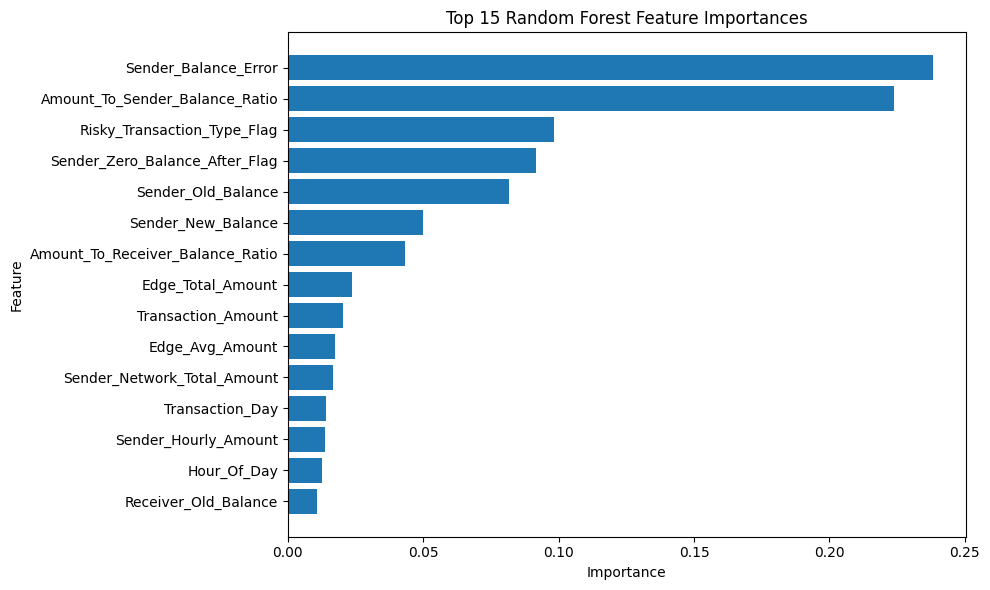

In [21]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

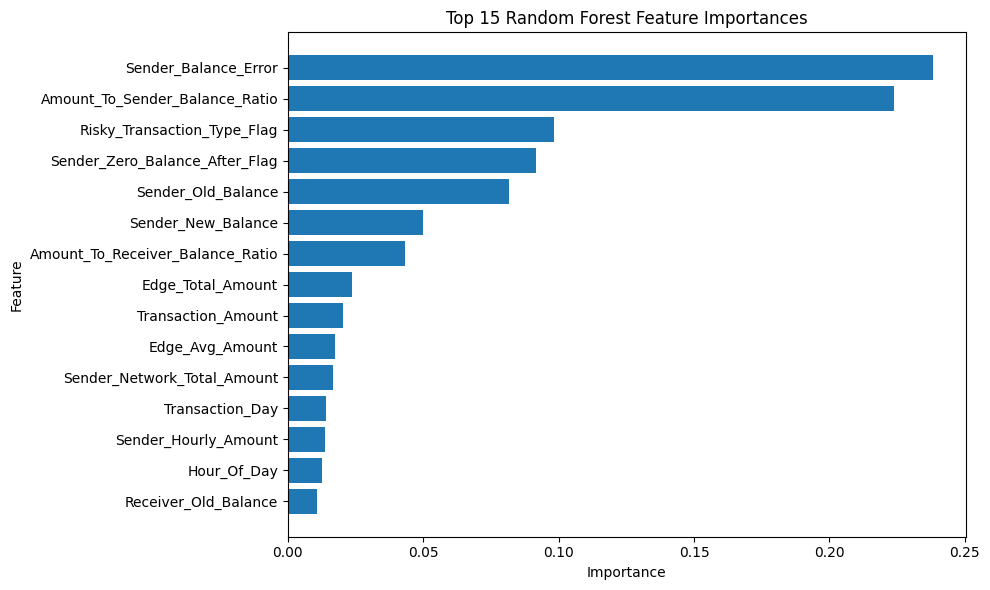

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("data/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
import os
os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'final_hybrid_risk_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_comparison_results.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_final_hybrid_risk.csv',
 'model_dataset_network_risk.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'network_risk_fraud_summary.csv',
 'night_fraud_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'random_forest_feature_importance.csv',
 'random_forest_feature_importance.png',
 'receiver_account_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_transactions_processed_step1.csv',
 'upi_transactions_processed_step2.csv',
 'upi_transactions_pro

In [24]:
import os

os.makedirs("models", exist_ok=True)

os.listdir()

['.ipynb_checkpoints',
 '01_data_understanding.ipynb.ipynb',
 'dashboard',
 'data',
 'images',
 'models',
 'notebooks',
 'reports',
 'src']

In [25]:
import joblib

joblib.dump(rf_model_strict, "models/fraudshield_random_forest_model.pkl")

['models/fraudshield_random_forest_model.pkl']

In [26]:
joblib.dump(strict_ml_features, "models/strict_ml_features.pkl")

['models/strict_ml_features.pkl']

In [27]:
import json

model_metadata = {
    "project_name": "FraudShield X: UPI Mule Ring Early-Warning System Using Temporal Graph Risk Signals",
    "model_name": "Strict Random Forest Classifier",
    "target_column": "Fraud_Label",
    "feature_count": len(strict_ml_features),
    "training_rows": int(X_train.shape[0]),
    "testing_rows": int(X_test.shape[0]),
    "accuracy": float(model_results.loc[model_results["Model"] == "Strict Random Forest", "Accuracy"].values[0]),
    "precision": float(model_results.loc[model_results["Model"] == "Strict Random Forest", "Precision"].values[0]),
    "recall": float(model_results.loc[model_results["Model"] == "Strict Random Forest", "Recall"].values[0]),
    "f1_score": float(model_results.loc[model_results["Model"] == "Strict Random Forest", "F1_Score"].values[0]),
    "roc_auc": float(model_results.loc[model_results["Model"] == "Strict Random Forest", "ROC_AUC"].values[0]),
    "leakage_control": "Strict transaction-time features used. Fraud-label-derived features and final risk-score features excluded from ML training."
}

with open("models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

model_metadata

{'project_name': 'FraudShield X: UPI Mule Ring Early-Warning System Using Temporal Graph Risk Signals',
 'model_name': 'Strict Random Forest Classifier',
 'target_column': 'Fraud_Label',
 'feature_count': 31,
 'training_rows': 406570,
 'testing_rows': 101643,
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 0.997,
 'f1_score': 0.9985,
 'roc_auc': 0.9997,
 'leakage_control': 'Strict transaction-time features used. Fraud-label-derived features and final risk-score features excluded from ML training.'}

In [28]:
os.listdir("models")

['fraudshield_random_forest_model.pkl',
 'model_metadata.json',
 'strict_ml_features.pkl']

In [29]:
loaded_model = joblib.load("models/fraudshield_random_forest_model.pkl")
loaded_features = joblib.load("models/strict_ml_features.pkl")

loaded_model, len(loaded_features)

(RandomForestClassifier(class_weight='balanced', max_depth=12,
                        min_samples_split=10, n_jobs=-1, random_state=42),
 31)

In [ ]:
## Final Model Saving

The best-performing strict no-leakage model was saved using Joblib.

Saved artifacts include:

- Trained Random Forest model
- Strict ML feature list
- Model metadata JSON file

This allows the model to be reused later for prediction, deployment, or integration into a Streamlit/FastAPI application.

In [30]:
sample_transaction = X_test.iloc[[0]]

sample_transaction

,Transaction_Amount,Transaction_Day,Hour_Of_Day,Night_Transaction_Flag,Sender_Old_Balance,Sender_New_Balance,Receiver_Old_Balance,Receiver_New_Balance,Sender_Balance_Error,Receiver_Balance_Error,...,Receiver_Velocity_Risk_Flag,Sender_Network_OutDegree,Sender_Network_Total_Amount,Sender_Network_Txn_Count,Receiver_Network_InDegree,Receiver_Network_Total_Amount,Receiver_Network_Txn_Count,Edge_Txn_Count,Edge_Total_Amount,Edge_Avg_Amount
65229,150.65,11,16,0,0.0,0.0,0.0,0.0,-150.65,150.65,...,1,1,150.65,1,1,150.65,1,1,150.65,150.65


In [31]:
sample_prediction = loaded_model.predict(sample_transaction)
sample_probability = loaded_model.predict_proba(sample_transaction)[:, 1]

sample_prediction, sample_probability

(array([0]), array([0.]))

In [32]:
actual_label = y_test.iloc[0]

print("Predicted Label:", sample_prediction[0])
print("Fraud Probability:", round(sample_probability[0], 4))
print("Actual Label:", actual_label)

Predicted Label: 0
Fraud Probability: 0.0
Actual Label: 0


In [33]:
def predict_fraud(transaction_data):
    prediction = loaded_model.predict(transaction_data)[0]
    probability = loaded_model.predict_proba(transaction_data)[:, 1][0]

    if prediction == 1:
        risk_status = "Fraud / High Risk"
    else:
        risk_status = "Genuine / Low Risk"

    return {
        "prediction": int(prediction),
        "fraud_probability": round(float(probability), 4),
        "risk_status": risk_status
    }

In [34]:
predict_fraud(sample_transaction)

{'prediction': 0,
 'fraud_probability': 0.0,
 'risk_status': 'Genuine / Low Risk'}

In [35]:
fraud_sample = X_test[y_test == 1].iloc[[0]]

predict_fraud(fraud_sample)

{'prediction': 1,
 'fraud_probability': 0.9998,
 'risk_status': 'Fraud / High Risk'}

In [36]:
genuine_sample = X_test[y_test == 0].iloc[[0]]

predict_fraud(genuine_sample)

{'prediction': 0,
 'fraud_probability': 0.0,
 'risk_status': 'Genuine / Low Risk'}

In [ ]:
## Single Transaction Prediction Test

The saved Random Forest model was loaded successfully and tested on individual transactions.

A prediction function was created to return:

- Predicted fraud label
- Fraud probability
- Risk status

This confirms that the trained model can be reused for real-time or batch fraud prediction.

In [37]:
project_metrics_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions Used",
        "Total Genuine Transactions",
        "Total Fraud Transactions",
        "Fraud Percentage",
        "Final Dataset Columns",
        "Strict ML Feature Count",
        "Best Model",
        "Best Model Recall",
        "Best Model F1 Score",
        "Best Model ROC-AUC"
    ],
    "Value": [
        len(df_model),
        int(df_model["Fraud_Label"].value_counts()[0]),
        int(df_model["Fraud_Label"].value_counts()[1]),
        round(df_model["Fraud_Label"].mean() * 100, 4),
        df_model.shape[1],
        len(strict_ml_features),
        "Strict Random Forest",
        float(model_results.loc[model_results["Model"] == "Strict Random Forest", "Recall"].values[0]),
        float(model_results.loc[model_results["Model"] == "Strict Random Forest", "F1_Score"].values[0]),
        float(model_results.loc[model_results["Model"] == "Strict Random Forest", "ROC_AUC"].values[0])
    ]
})

project_metrics_summary

,Metric,Value
0,Total Transactions Used,508213
1,Total Genuine Transactions,500000
2,Total Fraud Transactions,8213
3,Fraud Percentage,1.6161
4,Final Dataset Columns,66
5,Strict ML Feature Count,31
6,Best Model,Strict Random Forest
7,Best Model Recall,0.997
8,Best Model F1 Score,0.9985
9,Best Model ROC-AUC,0.9997


In [38]:
risk_layer_summary = pd.DataFrame({
    "Risk Layer": [
        "Transaction Risk Layer",
        "Temporal Burst Risk Layer",
        "Graph / Network Risk Layer",
        "Final Hybrid Risk Layer"
    ],
    "Output File": [
        "transaction_risk_level_summary.csv",
        "temporal_risk_fraud_summary.csv",
        "network_risk_fraud_summary.csv",
        "final_hybrid_risk_summary.csv"
    ],
    "Purpose": [
        "Detects suspicious transaction amount, balance, and transaction-type behavior",
        "Detects sudden high-frequency or high-value sender/receiver activity",
        "Detects mule-ring behavior using sender-receiver network relationships",
        "Combines transaction, temporal, network, and account-level signals into one score"
    ]
})

risk_layer_summary

,Risk Layer,Output File,Purpose
0,Transaction Risk Layer,transaction_risk_level_summary.csv,"Detects suspicious transaction amount, balance..."
1,Temporal Burst Risk Layer,temporal_risk_fraud_summary.csv,Detects sudden high-frequency or high-value se...
2,Graph / Network Risk Layer,network_risk_fraud_summary.csv,Detects mule-ring behavior using sender-receiv...
3,Final Hybrid Risk Layer,final_hybrid_risk_summary.csv,"Combines transaction, temporal, network, and a..."


In [39]:
top_10_feature_importance = feature_importance.head(10)

top_10_feature_importance

,Feature,Importance
0,Sender_Balance_Error,0.238402
1,Amount_To_Sender_Balance_Ratio,0.223865
2,Risky_Transaction_Type_Flag,0.098420
3,Sender_Zero_Balance_After_Flag,0.091528
4,Sender_Old_Balance,0.081674
5,Sender_New_Balance,0.050010
6,Amount_To_Receiver_Balance_Ratio,0.043130
7,Edge_Total_Amount,0.023558
8,Transaction_Amount,0.020195
9,Edge_Avg_Amount,0.017385


In [40]:
project_metrics_summary.to_csv("data/project_metrics_summary.csv", index=False)
risk_layer_summary.to_csv("data/risk_layer_summary.csv", index=False)
top_10_feature_importance.to_csv("data/top_10_feature_importance.csv", index=False)

In [41]:
import os
os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'final_hybrid_risk_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_comparison_results.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_final_hybrid_risk.csv',
 'model_dataset_network_risk.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'network_risk_fraud_summary.csv',
 'night_fraud_summary.csv',
 'project_metrics_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'random_forest_feature_importance.csv',
 'random_forest_feature_importance.png',
 'receiver_account_summary.csv',
 'risk_layer_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_10_feature_importance.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_trans

In [ ]:
## Final Project Summary Tables

Final summary tables were created for reporting and dashboard use.

The summary files include:

- Project-level metrics
- Risk-layer descriptions
- Top feature-importance results

These outputs make the project easier to explain in reports, resumes, dashboards, and interviews.

In [42]:
import os

os.listdir()

['.ipynb_checkpoints',
 '01_data_understanding.ipynb.ipynb',
 'dashboard',
 'data',
 'images',
 'models',
 'notebooks',
 'reports',
 'src']

In [43]:
data_files = os.listdir("data")
len(data_files), data_files

(33,
 ['account_mule_risk_features.csv',
  'amount_bucket_fraud_summary.csv',
  'amount_by_fraud_summary.csv',
  'day_fraud_summary.csv',
  'final_hybrid_risk_summary.csv',
  'fraud_imbalance_summary.csv',
  'hour_fraud_summary.csv',
  'model_comparison_results.csv',
  'model_dataset_account_risk_sample.csv',
  'model_dataset_final_hybrid_risk.csv',
  'model_dataset_network_risk.csv',
  'model_dataset_temporal_risk.csv',
  'model_dataset_transaction_risk.csv',
  'network_risk_fraud_summary.csv',
  'night_fraud_summary.csv',
  'project_metrics_summary.csv',
  'PS_20174392719_1491204439457_log.csv',
  'random_forest_feature_importance.csv',
  'random_forest_feature_importance.png',
  'receiver_account_summary.csv',
  'risk_layer_summary.csv',
  'sender_account_summary.csv',
  'temporal_risk_fraud_summary.csv',
  'top_10_feature_importance.csv',
  'top_fraud_receivers.csv',
  'top_fraud_senders.csv',
  'top_mule_risk_accounts.csv',
  'transaction_risk_level_summary.csv',
  'transaction_ty

In [44]:
model_files = os.listdir("models")
len(model_files), model_files

(3,
 ['fraudshield_random_forest_model.pkl',
  'model_metadata.json',
  'strict_ml_features.pkl'])

In [45]:
project_structure = pd.DataFrame({
    "Folder": [
        "data",
        "models",
        "notebooks",
        "reports",
        "images",
        "dashboard",
        "src"
    ],
    "Purpose": [
        "Stores raw, processed, feature-engineered, summary, and model-result CSV files",
        "Stores trained model, feature list, and model metadata files",
        "Stores Jupyter notebooks for EDA, feature engineering, and ML modeling",
        "Stores final reports, documentation, and presentation exports",
        "Stores charts, plots, and visual assets",
        "Stores Streamlit or dashboard application files",
        "Stores reusable Python scripts and helper functions"
    ]
})

project_structure

,Folder,Purpose
0,data,"Stores raw, processed, feature-engineered, sum..."
1,models,"Stores trained model, feature list, and model ..."
2,notebooks,"Stores Jupyter notebooks for EDA, feature engi..."
3,reports,"Stores final reports, documentation, and prese..."
4,images,"Stores charts, plots, and visual assets"
5,dashboard,Stores Streamlit or dashboard application files
6,src,Stores reusable Python scripts and helper func...


In [46]:
os.listdir("data")

['account_mule_risk_features.csv',
 'amount_bucket_fraud_summary.csv',
 'amount_by_fraud_summary.csv',
 'day_fraud_summary.csv',
 'final_hybrid_risk_summary.csv',
 'fraud_imbalance_summary.csv',
 'hour_fraud_summary.csv',
 'model_comparison_results.csv',
 'model_dataset_account_risk_sample.csv',
 'model_dataset_final_hybrid_risk.csv',
 'model_dataset_network_risk.csv',
 'model_dataset_temporal_risk.csv',
 'model_dataset_transaction_risk.csv',
 'network_risk_fraud_summary.csv',
 'night_fraud_summary.csv',
 'project_metrics_summary.csv',
 'PS_20174392719_1491204439457_log.csv',
 'random_forest_feature_importance.csv',
 'random_forest_feature_importance.png',
 'receiver_account_summary.csv',
 'risk_layer_summary.csv',
 'sender_account_summary.csv',
 'temporal_risk_fraud_summary.csv',
 'top_10_feature_importance.csv',
 'top_fraud_receivers.csv',
 'top_fraud_senders.csv',
 'top_mule_risk_accounts.csv',
 'transaction_risk_level_summary.csv',
 'transaction_type_fraud_summary.csv',
 'upi_trans

In [ ]:
## Final Project Structure

A clean project folder structure was prepared for professional presentation.

Main folders include:

- `data`: raw, processed, and summary datasets
- `models`: trained model and metadata
- `notebooks`: development notebooks
- `reports`: final documentation
- `images`: charts and visual assets
- `dashboard`: dashboard or Streamlit app files
- `src`: reusable Python scripts

This structure makes the project easier to maintain, explain, and deploy.

In [47]:
project_structure.to_csv("data/project_structure_summary.csv", index=False)

import os
"project_structure_summary.csv" in os.listdir("data")

True

In [49]:
readme_lines = [
"# FraudShield X: UPI Mule Ring Early-Warning System Using Temporal Graph Risk Signals",
"",
"## Project Overview",
"",
"FraudShield X is an advanced fraud detection and mule-risk intelligence project designed to identify suspicious UPI-style transaction behavior using multi-layer risk signals.",
"",
"The project combines:",
"",
"- Transaction-level fraud indicators",
"- Account-level mule-risk features",
"- Temporal burst-risk signals",
"- Graph/network relationship features",
"- Final hybrid risk scoring",
"- Machine learning fraud classification",
"- Model interpretation and feature importance",
"",
"The goal is to build an early-warning system that can detect high-risk transactions and mule-ring behavior before large-scale fraud escalation.",
"",
"---",
"",
"## Dataset",
"",
"- 508,213 final sampled transactions",
"- 500,000 genuine transactions",
"- 8,213 fraud transactions",
"- 1.6161% fraud rate",
"- 31 strict no-leakage ML features",
"- 66 final dataset columns",
"",
"---",
"",
"## Key Risk Layers",
"",
"### 1. Transaction Risk Layer",
"",
"Detects suspicious transaction behavior using transaction amount, sender/receiver balance changes, zero-balance flags, risky transaction type indicators, and amount-to-balance ratios.",
"",
"### 2. Account Mule-Risk Layer",
"",
"Creates sender and receiver account-level risk signals such as total transaction count, fraud involvement indicators, pass-through behavior, in-out transaction ratio, and mule-risk score.",
"",
"### 3. Temporal Burst-Risk Layer",
"",
"Detects sudden high-frequency or high-value activity using sender/receiver hourly transaction counts, hourly amounts, and velocity-risk flags.",
"",
"### 4. Graph / Network Risk Layer",
"",
"Uses sender-receiver relationship features such as sender network out-degree, receiver network in-degree, edge transaction count, edge total amount, edge average amount, and network risk score.",
"",
"### 5. Final Hybrid Risk Layer",
"",
"Combines transaction, temporal, network, and account-level risk signals into one final hybrid score for transaction-level early warning.",
"",
"---",
"",
"## Machine Learning Models",
"",
"Two strict no-leakage models were trained using only transaction-time features:",
"",
"| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |",
"|---|---:|---:|---:|---:|---:|",
"| Strict Logistic Regression | 0.9719 | 0.3622 | 0.9738 | 0.5280 | 0.9959 |",
"| Strict Random Forest | 1.0000 | 1.0000 | 0.9970 | 0.9985 | 0.9997 |",
"",
"The Random Forest model achieved the best overall performance.",
"",
"---",
"",
"## Best Model",
"",
"**Strict Random Forest Classifier**",
"",
"- Accuracy: 1.0000",
"- Precision: 1.0000",
"- Recall: 0.9970",
"- F1 Score: 0.9985",
"- ROC-AUC: 0.9997",
"",
"---",
"",
"## Top Feature Importances",
"",
"1. Sender_Balance_Error",
"2. Amount_To_Sender_Balance_Ratio",
"3. Risky_Transaction_Type_Flag",
"4. Sender_Zero_Balance_After_Flag",
"5. Sender_Old_Balance",
"6. Sender_New_Balance",
"7. Amount_To_Receiver_Balance_Ratio",
"8. Edge_Total_Amount",
"9. Transaction_Amount",
"10. Edge_Avg_Amount",
"",
"These features show that fraud behavior is strongly linked to sender balance anomalies, high-risk transaction types, account-draining behavior, and network edge amount patterns.",
"",
"---",
"",
"## Leakage Control",
"",
"To avoid target leakage, fraud-label-derived features and final rule-based risk-score features were excluded from strict ML training.",
"",
"The project separates rule-based risk intelligence features from strict no-leakage machine learning features.",
"",
"---",
"",
"## Saved Artifacts",
"",
"### Data Outputs",
"",
"- project_metrics_summary.csv",
"- risk_layer_summary.csv",
"- model_comparison_results.csv",
"- random_forest_feature_importance.csv",
"- top_10_feature_importance.csv",
"- final_hybrid_risk_summary.csv",
"- network_risk_fraud_summary.csv",
"",
"### Model Outputs",
"",
"- fraudshield_random_forest_model.pkl",
"- strict_ml_features.pkl",
"- model_metadata.json",
"",
"---",
"",
"## Project Structure",
"",
"```text",
"FraudShield-X-UPI-Mule-Ring-Early-Warning/",
"|-- data/",
"|-- models/",
"|-- notebooks/",
"|-- reports/",
"|-- images/",
"|-- dashboard/",
"|-- src/",
"```",
"",
"---",
"",
"## Business Impact",
"",
"FraudShield X can help financial platforms detect high-risk transactions early, identify mule-account behavior, reduce fraud losses, improve investigation workflows, prioritize suspicious transaction networks, and support real-time fraud-risk scoring.",
"",
"---",
"",
"## Tech Stack",
"",
"- Python",
"- Pandas",
"- NumPy",
"- Scikit-learn",
"- Matplotlib",
"- Joblib",
"- Jupyter Notebook",
"",
"---",
"",
"## Final Outcome",
"",
"FraudShield X successfully combines behavioral analytics, temporal signals, network intelligence, and machine learning to create a strong fraud-risk detection system for UPI-style digital transactions."
]

readme_content = "\n".join(readme_lines)

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

import os
os.listdir()

['.ipynb_checkpoints',
 '01_data_understanding.ipynb.ipynb',
 'dashboard',
 'data',
 'images',
 'models',
 'notebooks',
 'README.md',
 'reports',
 'src']

In [50]:
"README.md" in os.listdir()

True

In [51]:
with open("README.md", "r", encoding="utf-8") as f:
    print(f.read()[:1000])

# FraudShield X: UPI Mule Ring Early-Warning System Using Temporal Graph Risk Signals

## Project Overview

FraudShield X is an advanced fraud detection and mule-risk intelligence project designed to identify suspicious UPI-style transaction behavior using multi-layer risk signals.

The project combines:

- Transaction-level fraud indicators
- Account-level mule-risk features
- Temporal burst-risk signals
- Graph/network relationship features
- Final hybrid risk scoring
- Machine learning fraud classification
- Model interpretation and feature importance

The goal is to build an early-warning system that can detect high-risk transactions and mule-ring behavior before large-scale fraud escalation.

---

## Dataset

- 508,213 final sampled transactions
- 500,000 genuine transactions
- 8,213 fraud transactions
- 1.6161% fraud rate
- 31 strict no-leakage ML features
- 66 final dataset columns

---

## Key Risk Layers

### 1. Transaction Risk Layer

Detects suspicious transaction behavior u

In [52]:
requirements = [
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "joblib",
    "jupyter",
    "notebook"
]

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(requirements))

import os
os.listdir()

['.ipynb_checkpoints',
 '01_data_understanding.ipynb.ipynb',
 'dashboard',
 'data',
 'images',
 'models',
 'notebooks',
 'README.md',
 'reports',
 'requirements.txt',
 'src']

In [53]:
"requirements.txt" in os.listdir()

True

In [54]:
with open("requirements.txt", "r", encoding="utf-8") as f:
    print(f.read())

pandas
numpy
scikit-learn
matplotlib
joblib
jupyter
notebook


In [55]:
gitignore_lines = [
    "# Python cache files",
    "__pycache__/",
    "*.pyc",
    "*.pyo",
    "",
    "# Jupyter checkpoints",
    ".ipynb_checkpoints/",
    "",
    "# Virtual environments",
    "venv/",
    ".venv/",
    "env/",
    "",
    "# System files",
    ".DS_Store",
    "Thumbs.db",
    "",
    "# Large raw data files",
    "data/PS_20174392719_1491204439457_log.csv",
    "data/upi_transactions_raw.csv",
    "",
    "# Model binary files",
    "models/*.pkl",
    "",
    "# Temporary files",
    "*.tmp",
    "*.log"
]

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write("\n".join(gitignore_lines))

import os
os.listdir()

['.gitignore',
 '.ipynb_checkpoints',
 '01_data_understanding.ipynb.ipynb',
 'dashboard',
 'data',
 'images',
 'models',
 'notebooks',
 'README.md',
 'reports',
 'requirements.txt',
 'src']

In [56]:
".gitignore" in os.listdir()

True

In [57]:
with open(".gitignore", "r", encoding="utf-8") as f:
    print(f.read())

# Python cache files
__pycache__/
*.pyc
*.pyo

# Jupyter checkpoints
.ipynb_checkpoints/

# Virtual environments
venv/
.venv/
env/

# System files
.DS_Store
Thumbs.db

# Large raw data files
data/PS_20174392719_1491204439457_log.csv
data/upi_transactions_raw.csv

# Model binary files
models/*.pkl

# Temporary files
*.tmp
*.log
